# Load Amarillovirales Alignments and FASTA Files

This notebook reads:
- PHYLIP alignment files (`.aln`) from each subfolder in `dataset/Amarillovirales`
- FASTA files (`.fasta` and `.fa`) from the same folders

It then builds two separate pandas DataFrames:
1. `fasta_df` for FASTA sequences
2. `phylip_df` for PHYLIP alignment entries

Both DataFrames are indexed by sequence/alignment identifier.

In [1]:
from pathlib import Path
import pandas as pd

# Root folder containing the Amarillovirales subgroup folders
base_dir = Path("/home/dmoi/projects/ESM3di/polyprotein_cut/dataset/Amarillovirales")

subfolders = sorted([p for p in base_dir.iterdir() if p.is_dir()])
print("Subfolders:")
for s in subfolders:
    print("-", s.name)

# Discover FASTA and PHYLIP alignment files in each subfolder
fasta_files = []
phylip_files = []
for folder in subfolders:
    fasta_files.extend(sorted(folder.glob("*.fasta")))
    fasta_files.extend(sorted(folder.glob("*.fa")))
    phylip_files.extend(sorted(folder.glob("*.aln")))

print("\nFASTA files found:", len(fasta_files))
for f in fasta_files:
    print("-", f)

print("\nPHYLIP (.aln) files found:", len(phylip_files))
for f in phylip_files:
    print("-", f)

Subfolders:
- Hepacivirus-CHH
- Orthoflavivirus-CHH
- Pegivirus-CHH
- Pestivirus-CHH

FASTA files found: 6
- /home/dmoi/projects/ESM3di/polyprotein_cut/dataset/Amarillovirales/Hepacivirus-CHH/Hepacivirus.fasta
- /home/dmoi/projects/ESM3di/polyprotein_cut/dataset/Amarillovirales/Orthoflavivirus-CHH/orthoflavivirus.fasta
- /home/dmoi/projects/ESM3di/polyprotein_cut/dataset/Amarillovirales/Orthoflavivirus-CHH/Orthoflavivirus_preliminary_removeGap2.fa
- /home/dmoi/projects/ESM3di/polyprotein_cut/dataset/Amarillovirales/Pegivirus-CHH/pegivirus.fasta
- /home/dmoi/projects/ESM3di/polyprotein_cut/dataset/Amarillovirales/Pegivirus-CHH/pegivirus_per chain.fasta
- /home/dmoi/projects/ESM3di/polyprotein_cut/dataset/Amarillovirales/Pestivirus-CHH/Pestivirus.fasta

PHYLIP (.aln) files found: 5
- /home/dmoi/projects/ESM3di/polyprotein_cut/dataset/Amarillovirales/Hepacivirus-CHH/MF_00001.aln
- /home/dmoi/projects/ESM3di/polyprotein_cut/dataset/Amarillovirales/Orthoflavivirus-CHH/MF_00003.aln
- /home/d

In [2]:
from Bio import SeqIO


def parse_fasta(path: Path):
    records = []
    for record in SeqIO.parse(str(path), "fasta"):
        records.append(
            {
                "identifier": record.id,
                "sequence": str(record.seq),
                "source_file": str(path),
            }
        )
    return records


fasta_records = []
for fasta_path in fasta_files:
    fasta_records.extend(parse_fasta(fasta_path))

fasta_df = pd.DataFrame(fasta_records)
if not fasta_df.empty:
    fasta_df = fasta_df.set_index("identifier").sort_index()

print("FASTA dataframe shape:", fasta_df.shape)
fasta_df.head(10)

FASTA dataframe shape: (1748, 2)


,sequence,source_file
identifier,,
A0A024B7W1_001,SPQDNQMAIIIMVAVGLLGLITA,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...
A0A024B7W1_002,MKNPKKKSGGFRIVNMLKRGVARVSPFGGLKRLPAGLLLGHGPIRM...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...
A0A024B7W1_003,AEVTRRGSAYYMYLDRNDAGEAISFPTTLGMNKCYIQIMDLGHMCD...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...
A0A024B7W1_004,AEVTRRGSAYYMYLDRNDAGEAISFPTTLGMNKCYIQIMDLGHMCD...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...
A0A024B7W1_005,AVTLPSHSTRKLQTRSQTWLESREYTKHLIRVENWIFRNPGFALAA...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...
A0A024B7W1_006,IRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIELV...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...
A0A024B7W1_007,DVGCSVDFSKKETRCGTGVFVYNDVEAWRDRYKYHPDSPRRLAAAV...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...
A0A024B7W1_008,GSTDHMDHFSLGVLVILLMVQEGLKKRMTTKIIISTSMAVLVAMIL...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...
A0A024B7W1_009,SWPPSEVLTAVGLICALAGGFAKADIEMAGPMAAVGLLIVSYVVSG...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...


In [6]:
from Bio import AlignIO
import re


def detect_alignment_format(path: Path):
    """Infer alignment format from the first non-empty line."""
    first_nonempty = ""
    with path.open("r", encoding="utf-8", errors="ignore") as handle:
        for line in handle:
            stripped = line.strip()
            if stripped:
                first_nonempty = stripped
                break

    upper = first_nonempty.upper()

    # PHYLIP first line is typically: <nseq> <length>
    parts = first_nonempty.split()
    if len(parts) >= 2 and parts[0].isdigit() and parts[1].isdigit():
        return "phylip"

    if upper.startswith("CLUSTAL"):
        return "clustal"

    return "unknown"


def parse_clustal_fallback(path: Path):
    """
    Parse CLUSTAL-like alignments that may violate strict CLUSTAL formatting.
    Handles:
    - identifiers containing spaces
    - optional trailing position numbers
    - consensus-only lines made of *:. and spaces
    """
    seq_by_id = {}
    order = []

    with path.open("r", encoding="utf-8", errors="ignore") as handle:
        for raw_line in handle:
            line = raw_line.rstrip("\n")
            stripped = line.strip()

            if not stripped:
                continue

            upper = stripped.upper()
            if upper.startswith("CLUSTAL"):
                continue

            # Consensus rows typically contain only these symbols/spaces.
            if all(ch in "*:. -" for ch in stripped):
                continue

            # Capture: <identifier> <sequence_chunk> [optional_number]
            # Identifier can contain spaces; sequence is the rightmost AA/gap token.
            m = re.match(r"^(?P<ident>.+?)\s+([A-Za-z\-\.]+)(?:\s+\d+)?\s*$", line)
            if not m:
                continue

            ident = m.group("ident").strip()
            seq_chunk = re.search(r"([A-Za-z\-\.]+)(?:\s+\d+)?\s*$", line).group(1)

            if ident not in seq_by_id:
                seq_by_id[ident] = []
                order.append(ident)
            seq_by_id[ident].append(seq_chunk)

    return [
        {
            "identifier": ident,
            "alignment_sequence": "".join(seq_by_id[ident]),
            "source_file": str(path),
            "detected_format": "clustal",
            "parsed_as": "clustal-fallback",
        }
        for ident in order
    ]


def parse_alignment_biopython(path: Path):
    """
    Parse alignment files with Biopython using format detection + fallbacks.
    Returns one row per alignment entry.
    """
    detected = detect_alignment_format(path)

    if detected == "phylip":
        formats_to_try = ["phylip", "phylip-sequential", "phylip-relaxed"]
    elif detected == "clustal":
        formats_to_try = ["clustal"]
    else:
        # Conservative fallback list for mislabeled files.
        formats_to_try = ["clustal", "phylip", "phylip-sequential", "phylip-relaxed"]

    last_error = None
    for fmt in formats_to_try:
        try:
            aln = AlignIO.read(str(path), fmt)
            return [
                {
                    "identifier": rec.id,
                    "alignment_sequence": str(rec.seq),
                    "source_file": str(path),
                    "detected_format": detected,
                    "parsed_as": fmt,
                }
                for rec in aln
            ]
        except Exception as exc:
            last_error = exc

    # Non-standard CLUSTAL fallback.
    if detected == "clustal":
        fallback_records = parse_clustal_fallback(path)
        if fallback_records:
            return fallback_records

    raise ValueError(f"Alignment parse failed (detected={detected}): {last_error}")


phylip_records = []
failed_phylip = []
for aln_path in phylip_files:
    try:
        phylip_records.extend(parse_alignment_biopython(aln_path))
    except Exception as exc:
        failed_phylip.append((str(aln_path), str(exc)))

phylip_df = pd.DataFrame(phylip_records)
if not phylip_df.empty:
    phylip_df = phylip_df.set_index("identifier").sort_index()

print("Alignment dataframe shape:", phylip_df.shape)
if failed_phylip:
    print("\nFiles that failed alignment parsing:")
    for fpath, err in failed_phylip:
        print("-", fpath, "->", err)

phylip_df.head(10)

Alignment dataframe shape: (231, 4)


,alignment_sequence,source_file,detected_format,parsed_as
identifier,,,,
A0A097NZA3_9FLAV,MSHSEPGITGGRFPAYSLIGSCGGPRRFRCKPSMACNLFFNFPSTK...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback
A0A0B5HK21_9FLAV,--------------------------MSNKSKNQKPKPQRGPRGRV...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback
A0A0C4PNF2_9FLAV,--MSKKPGGPGKNRVVNMLKRGASRAG---------PLQALKRMLG...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback
A0A0C4W3V9_9FLAV,----MLNNSKLKKPSGGGQRAS------------------GRRKKP...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback
A0A0C4W3V9_9FLAV,-MLNNSKLKKPSGGGQRASGRRKKPSSQPV----------------...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback
A0A1B0Z5J8_9FLAV,----------------------------------------------...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback
A0A1Z3MI02_9FLAV,MEFKILNNTKKKNNNE---EEAEGNMFWRMYRRPPPGCYEPTYNLS...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback
A0A247ZNN0_9FLAV,---------------------------------MACNLFFNFPSTK...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback
A0A2H4GY08_ZIKV,--MKNPKKKSGGFRIVNMLKRGVARVS---------PFGGLKRLPA...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback


In [7]:
#create a column with the length of the alignment sequence and the length of the original sequence
#also create a column with gap percentage in the alignment sequence and original sequence

phylip_df["alignment_length"] = phylip_df["alignment_sequence"].apply(len)	
phylip_df["alignment_gap_percentage"] = phylip_df["alignment_sequence"].apply(lambda seq: (seq.count("-") / len(seq)) * 100 if len(seq) > 0 else None)
#remove - to find length of original sequence
phylip_df["original_length"] = phylip_df["alignment_sequence"].apply(lambda seq: len(seq.replace("-", "")))
phylip_df["original_sequence"] = phylip_df["alignment_sequence"].apply(lambda seq: seq.replace("-", ""))
phylip_df.head(10)

,alignment_sequence,source_file,detected_format,parsed_as,alignment_length,alignment_gap_percentage,original_length,original_sequence
identifier,,,,,,,,
A0A097NZA3_9FLAV,MSHSEPGITGGRFPAYSLIGSCGGPRRFRCKPSMACNLFFNFPSTK...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback,3202,6.589631,2991,MSHSEPGITGGRFPAYSLIGSCGGPRRFRCKPSMACNLFFNFPSTK...
A0A0B5HK21_9FLAV,--------------------------MSNKSKNQKPKPQRGPRGRV...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback,3202,8.119925,2942,MSNKSKNQKPKPQRGPRGRVRGQSRSGPVVFPSGAVLVGGRYIPPP...
A0A0C4PNF2_9FLAV,--MSKKPGGPGKNRVVNMLKRGASRAG---------PLQALKRMLG...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback,3525,2.780142,3427,MSKKPGGPGKNRVVNMLKRGASRAGPLQALKRMLGELLDGRGPIRF...
A0A0C4W3V9_9FLAV,----MLNNSKLKKPSGGGQRAS------------------GRRKKP...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback,3539,4.690591,3373,MLNNSKLKKPSGGGQRASGRRKKPSSQPVPMNLVMGVVHYATHIAL...
A0A0C4W3V9_9FLAV,-MLNNSKLKKPSGGGQRASGRRKKPSSQPV----------------...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback,3525,4.283688,3374,MLNNSKLKKPSGGGQRASGRRKKPSSQPVPMNLVMGVVHYATHIAL...
A0A1B0Z5J8_9FLAV,----------------------------------------------...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback,3882,23.441525,2972,MLLPFLLVLPLVGGARTPASHACMVDGSFVLSNCCSPFDVYYCLPC...
A0A1Z3MI02_9FLAV,MEFKILNNTKKKNNNE---EEAEGNMFWRMYRRPPPGCYEPTYNLS...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback,4162,5.742432,3923,MEFKILNNTKKKNNNEEEAEGNMFWRMYRRPPPGCYEPTYNLSGTP...
A0A247ZNN0_9FLAV,---------------------------------MACNLFFNFPSTK...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback,3202,7.620237,2958,MACNLFFNFPSTKKNQTKSVLHLWWNLCVCVCGVVMSKPVRPGQYI...
A0A2H4GY08_ZIKV,--MKNPKKKSGGFRIVNMLKRGVARVS---------PFGGLKRLPA...,/home/dmoi/projects/ESM3di/polyprotein_cut/dat...,clustal,clustal-fallback,3525,2.893617,3423,MKNPKKKSGGFRIVNMLKRGVARVSPFGGLKRLPAGLLLGHGPIRM...


## Sequence Loading and Alignment QC Complete

At this stage, the sequence data has been loaded, and alignment-level quality features have been computed, including:

- **Alignment length**
- **Gap percentage**
- **Original (ungapped) sequence length**

## Next Step: Build ESM3Di Embeddings

The next step is to generate an **embedding matrix per sequence** using the **ESM3Di** model.  
These embeddings will serve as fixed input features for downstream cut-site prediction.

## Cut-Site Prediction Strategy

- Keep the **ESM3Di backbone frozen** (no fine-tuning of the base model).
- Train a **lightweight classifier head** on top of residue-level embeddings.
- Use **original protein sequences** with their corresponding **cut-site labels** as supervision.

This setup isolates learning to the classifier while leveraging pretrained ESM3Di representations for residue-level cleavage prediction.

In [11]:
# Create an embedding matrix (n_AA x d_embedding) for each sequence using ESM3Di
from pathlib import Path
import numpy as np
import torch
from transformers import AutoTokenizer, T5Tokenizer

from esm3di import ESM3DiModel


def build_model_from_checkpoint(checkpoint_path: str, requested_revision: str = "46c5f7d"):
    """Build ESM3Di using checkpoint args (same pattern as HIV_LLManalysis notebook)."""
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    args_dict = checkpoint.get("args", {})

    hf_model_name = args_dict.get(
        "hf_model_name",
        args_dict.get("hf_model", "facebook/esm2_t33_650M_UR50D"),
    )
    resolved_model_revision = args_dict.get("revision", requested_revision)

    label_vocab = checkpoint.get("label_vocab") or []
    num_labels = len(label_vocab) or int(args_dict.get("num_labels", 20))

    use_cnn_head = bool(args_dict.get("use_cnn_head", False))
    use_transformer_head = bool(args_dict.get("use_transformer_head", False))
    use_plddt_prediction_head = bool(args_dict.get("use_plddt_prediction_head", False))
    plddt_prediction_mode = args_dict.get("plddt_prediction_mode", "classification")

    lora_r = args_dict.get("lora_r", 8)
    lora_alpha = args_dict.get("lora_alpha", 16)
    lora_dropout = args_dict.get("lora_dropout", 0.05)
    target_modules = checkpoint.get("lora_target_modules", args_dict.get("target_modules"))

    print(f"Using model: {hf_model_name}")
    print(f"Using revision: {resolved_model_revision}")
    print(f"num_labels: {num_labels}")

    try:
        esm3di = ESM3DiModel(
            hf_model_name=hf_model_name,
            revision=resolved_model_revision,
            num_labels=num_labels,
            lora_r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=target_modules,
            use_cnn_head=use_cnn_head,
            cnn_num_layers=args_dict.get("cnn_num_layers", 2),
            cnn_kernel_size=args_dict.get("cnn_kernel_size", 3),
            cnn_dropout=args_dict.get("cnn_dropout", 0.1),
            use_transformer_head=use_transformer_head,
            use_plddt_prediction_head=use_plddt_prediction_head,
            plddt_num_bins=args_dict.get("plddt_num_bins", len(checkpoint.get("plddt_label_vocab") or []) or 10),
            plddt_prediction_mode=plddt_prediction_mode,
            transformer_head_dim=args_dict.get("transformer_head_dim", 256),
            transformer_head_layers=args_dict.get("transformer_head_layers", 2),
            transformer_head_dropout=args_dict.get("transformer_head_dropout", 0.1),
            transformer_head_num_heads=args_dict.get("transformer_head_num_heads", None),
            use_iterative_transformer_head=args_dict.get("use_iterative_transformer_head", False),
            iterative_head_max_iterations=args_dict.get("iterative_head_max_iterations", 5),
            iterative_head_halt_threshold=args_dict.get("iterative_head_halt_threshold", 0.95),
            iterative_head_lambda_p=args_dict.get("iterative_head_lambda_p", 0.01),
            iterative_head_prior_p=args_dict.get("iterative_head_prior_p", 0.5),
            use_positional_encoding=args_dict.get("use_positional_encoding", True),
            use_hidden_state_feedback=args_dict.get("use_hidden_state_feedback", True),
            use_gru_gate=args_dict.get("use_gru_gate", False),
            aux_track_num_bins=checkpoint.get("aux_track_num_bins", args_dict.get("aux_track_num_bins", None)),
        )
    except ValueError as exc:
        if "Target modules" in str(exc):
            print("Checkpoint LoRA target modules incompatible with current base model; retrying with auto-discovery")
            esm3di = ESM3DiModel(
                hf_model_name=hf_model_name,
                revision=resolved_model_revision,
                num_labels=num_labels,
                lora_r=lora_r,
                lora_alpha=lora_alpha,
                lora_dropout=lora_dropout,
                target_modules=None,
                use_cnn_head=use_cnn_head,
                cnn_num_layers=args_dict.get("cnn_num_layers", 2),
                cnn_kernel_size=args_dict.get("cnn_kernel_size", 3),
                cnn_dropout=args_dict.get("cnn_dropout", 0.1),
                use_transformer_head=use_transformer_head,
                use_plddt_prediction_head=use_plddt_prediction_head,
                plddt_num_bins=args_dict.get("plddt_num_bins", len(checkpoint.get("plddt_label_vocab") or []) or 10),
                plddt_prediction_mode=plddt_prediction_mode,
                transformer_head_dim=args_dict.get("transformer_head_dim", 256),
                transformer_head_layers=args_dict.get("transformer_head_layers", 2),
                transformer_head_dropout=args_dict.get("transformer_head_dropout", 0.1),
                transformer_head_num_heads=args_dict.get("transformer_head_num_heads", None),
                use_iterative_transformer_head=args_dict.get("use_iterative_transformer_head", False),
                iterative_head_max_iterations=args_dict.get("iterative_head_max_iterations", 5),
                iterative_head_halt_threshold=args_dict.get("iterative_head_halt_threshold", 0.95),
                iterative_head_lambda_p=args_dict.get("iterative_head_lambda_p", 0.01),
                iterative_head_prior_p=args_dict.get("iterative_head_prior_p", 0.5),
                use_positional_encoding=args_dict.get("use_positional_encoding", True),
                use_hidden_state_feedback=args_dict.get("use_hidden_state_feedback", True),
                use_gru_gate=args_dict.get("use_gru_gate", False),
                aux_track_num_bins=checkpoint.get("aux_track_num_bins", args_dict.get("aux_track_num_bins", None)),
            )
        else:
            raise

    model = esm3di.get_model()
    model_state = checkpoint["model_state_dict"]
    if any(k.startswith("module.") for k in model_state):
        model_state = {k.replace("module.", "", 1): v for k, v in model_state.items()}

    load_result = model.load_state_dict(model_state, strict=False)
    if load_result.missing_keys:
        print(f"Missing keys: {len(load_result.missing_keys)}")
    if load_result.unexpected_keys:
        print(f"Unexpected keys: {len(load_result.unexpected_keys)}")

    return esm3di, model, hf_model_name


def get_tokenizer(esm3di_model, hf_model_name: str):
    if hasattr(esm3di_model, "tokenizer") and esm3di_model.tokenizer is not None:
        return esm3di_model.tokenizer
    if esm3di_model.is_t5:
        try:
            return T5Tokenizer.from_pretrained(hf_model_name, legacy=True, trust_remote_code=True)
        except Exception:
            return AutoTokenizer.from_pretrained(hf_model_name, trust_remote_code=True)
    return AutoTokenizer.from_pretrained(hf_model_name, do_lower_case=False, trust_remote_code=True)


def forward_for_hidden_states(model, input_ids, attention_mask):
    """
    Get hidden states robustly across wrappers.
    1) Try plain wrapper call (CNN wrapper already requests hidden states internally).
    2) If needed, retry with output_hidden_states.
    3) If PEFT TokenClassification label plumbing breaks, call LoRA-patched backbone.
    """
    try:
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        if hasattr(outputs, "hidden_states") and outputs.hidden_states is not None:
            return outputs
    except TypeError as exc:
        if "unexpected keyword argument 'labels'" not in str(exc):
            raise

    try:
        return model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True,
        )
    except TypeError as exc:
        if "unexpected keyword argument 'labels'" not in str(exc):
            raise

    if hasattr(model, "base_model") and hasattr(model.base_model, "model"):
        backbone = model.base_model.model
        return backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True,
        )

    raise RuntimeError("Could not retrieve hidden states from model")


def extract_embedding_matrices(model, tokenizer, sequences, is_t5: bool, device: str, batch_size: int = 8):
    matrices = []
    model = model.to(device)
    model.eval()

    with torch.no_grad():
        for i in range(0, len(sequences), batch_size):
            batch_raw = sequences[i:i + batch_size]
            batch_for_tok = [" ".join(list(s)) for s in batch_raw] if is_t5 else batch_raw

            enc = tokenizer(
                batch_for_tok,
                return_tensors="pt",
                padding=True,
                truncation=True,
                add_special_tokens=True,
                return_special_tokens_mask=True,
            )

            input_ids = enc["input_ids"].to(device)
            attention_mask = enc["attention_mask"].to(device)
            special_mask = enc["special_tokens_mask"].to(device)

            outputs = forward_for_hidden_states(model, input_ids=input_ids, attention_mask=attention_mask)
            if not hasattr(outputs, "hidden_states") or outputs.hidden_states is None:
                raise RuntimeError("Model output has no hidden_states; cannot extract embeddings")

            last_hidden = outputs.hidden_states[-1]

            for b_idx, raw_seq in enumerate(batch_raw):
                aa_mask = (attention_mask[b_idx] == 1) & (special_mask[b_idx] == 0)
                emb = last_hidden[b_idx][aa_mask]

                if emb.shape[0] != len(raw_seq):
                    n = min(emb.shape[0], len(raw_seq))
                    emb = emb[:n]

                matrices.append(emb.detach().cpu().numpy().astype(np.float32))

    return matrices


# -------- User-configurable checkpoint --------
checkpoint_path = "/home/dmoi/projects/ESM3di/checkpoints/esm3di_from_mlm/epoch_5.pt"
requested_revision = "46c5f7d"
# ---------------------------------------------

if not Path(checkpoint_path).exists():
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

if "original_sequence" in phylip_df.columns:
    seq_df = phylip_df.copy()
    seq_col = "original_sequence"
else:
    seq_df = fasta_df.copy()
    seq_col = "sequence"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

esm3di_model, esm_model, hf_model_name = build_model_from_checkpoint(
    checkpoint_path=checkpoint_path,
    requested_revision=requested_revision,
)
tokenizer = get_tokenizer(esm3di_model, hf_model_name)

sequences = seq_df[seq_col].astype(str).tolist()
embedding_mats = extract_embedding_matrices(
    model=esm_model,
    tokenizer=tokenizer,
    sequences=sequences,
    is_t5=esm3di_model.is_t5,
    device=device,
    batch_size=8,
)

embedding_df = seq_df.copy()
embedding_df["embedding_matrix"] = embedding_mats
embedding_df["n_AA"] = embedding_df["embedding_matrix"].apply(lambda x: int(x.shape[0]))
embedding_df["d_embedding"] = embedding_df["embedding_matrix"].apply(lambda x: int(x.shape[1]) if x.ndim == 2 else 0)

print("Embedding dataframe shape:", embedding_df.shape)
print("Example matrix shape:", embedding_df["embedding_matrix"].iloc[0].shape)
embedding_df[[seq_col, "n_AA", "d_embedding"]].head(10)

Using device: cuda
Using model: Synthyra/ESMplusplus_small
Using revision: 46c5f7d
num_labels: 20

Loading model: Synthyra/ESMplusplus_small


Loading weights: 100%|██████████| 308/308 [00:00<00:00, 1749.70it/s]
[transformers] ESMplusplusForTokenClassification LOAD REPORT from: Synthyra/ESMplusplus_small
Key                         | Status  | 
----------------------------+---------+-
classifier.{0, 2, 3}.bias   | MISSING | 
classifier.{0, 2, 3}.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 't

,original_sequence,n_AA,d_embedding
identifier,,,
A0A097NZA3_9FLAV,MSHSEPGITGGRFPAYSLIGSCGGPRRFRCKPSMACNLFFNFPSTK...,2991,960
A0A0B5HK21_9FLAV,MSNKSKNQKPKPQRGPRGRVRGQSRSGPVVFPSGAVLVGGRYIPPP...,2942,960
A0A0C4PNF2_9FLAV,MSKKPGGPGKNRVVNMLKRGASRAGPLQALKRMLGELLDGRGPIRF...,3427,960
A0A0C4W3V9_9FLAV,MLNNSKLKKPSGGGQRASGRRKKPSSQPVPMNLVMGVVHYATHIAL...,3373,960
A0A0C4W3V9_9FLAV,MLNNSKLKKPSGGGQRASGRRKKPSSQPVPMNLVMGVVHYATHIAL...,3374,960
A0A1B0Z5J8_9FLAV,MLLPFLLVLPLVGGARTPASHACMVDGSFVLSNCCSPFDVYYCLPC...,2972,960
A0A1Z3MI02_9FLAV,MEFKILNNTKKKNNNEEEAEGNMFWRMYRRPPPGCYEPTYNLSGTP...,3923,960
A0A247ZNN0_9FLAV,MACNLFFNFPSTKKNQTKSVLHLWWNLCVCVCGVVMSKPVRPGQYI...,2958,960
A0A2H4GY08_ZIKV,MKNPKKKSGGFRIVNMLKRGVARVSPFGGLKRLPAGLLLGHGPIRM...,3423,960


## Prepare Supervision for Cut-Site Prediction

We now have an embedding matrix for each sequence with shape **`(n_AA, d_embedding)`**.  
These embeddings are used as input features for a residue-level cut-site predictor.

### Learning Setup

This is a **supervised binary classification** problem at the residue level:

- **Input:** per-sequence embedding matrix `X ∈ R^(n_AA × d_embedding)`
- **Target:** per-residue binary label `y ∈ {0,1}^(n_AA)`
	- `1` = cut site
	- `0` = non-cut site

### Label Source

Cut-site annotations are extracted from **ICTV records** for each sequence identifier.  
From these annotations, we build:

- `cut_site_positions`: list of cut-site positions (1-based)
- `cut_site_mask`: binary vector aligned to each sequence length (`n_AA`)

These labels are then attached to `embedding_df` for downstream model training and evaluation.

In [15]:
# Parse ICTV annotation files and extract cleavage sites per sequence
import re
from pathlib import Path


def parse_ictv_cleavage_sites(ictv_file: Path):
    """
    Parse UniProt-like ICTV flat files and extract FT SITE ranges where note is Cleavage.

    Returns dict:
      {
        seq_id: {
          "ranges": [(start, end), ...],
          "positions_start": [start1, ...],
          "positions_end": [end1, ...],
        }
      }
    """
    by_id = {}
    current_id = None

    pending_site = None
    pending_is_cleavage = False

    def commit_pending(seq_id):
        nonlocal pending_site, pending_is_cleavage
        if seq_id is None or pending_site is None:
            pending_site = None
            pending_is_cleavage = False
            return
        if pending_is_cleavage:
            s, e = pending_site
            by_id[seq_id]["ranges"].append((s, e))
            by_id[seq_id]["positions_start"].append(s)
            by_id[seq_id]["positions_end"].append(e)
        pending_site = None
        pending_is_cleavage = False

    with ictv_file.open("r", encoding="utf-8", errors="ignore") as f:
        for raw in f:
            line = raw.rstrip("\n")

            # New record ID
            if line.startswith("ID"):
                commit_pending(current_id)
                m_id = re.match(r"^ID\s+([^\s]+)", line)
                current_id = m_id.group(1) if m_id else None
                if current_id and current_id not in by_id:
                    by_id[current_id] = {"ranges": [], "positions_start": [], "positions_end": []}
                continue

            # Record separator
            if line.startswith("//"):
                commit_pending(current_id)
                current_id = None
                continue

            if current_id is None:
                continue

            # FT SITE lines (e.g. FT   SITE            103..104)
            m_site = re.match(r"^FT\s+SITE\s+(\d+)\.\.(\d+)", line)
            if m_site:
                # Commit previous site block before starting a new one.
                commit_pending(current_id)
                pending_site = (int(m_site.group(1)), int(m_site.group(2)))
                pending_is_cleavage = False
                continue

            # Cleavage annotation on FT note line
            if pending_site is not None and "/note=\"Cleavage\"" in line:
                pending_is_cleavage = True
                continue

            # End of current SITE block when a new FT feature starts.
            if pending_site is not None and line.startswith("FT") and not line.startswith("FT                   "):
                commit_pending(current_id)
                continue

        # Flush at EOF
        commit_pending(current_id)

    # Remove records with no cleavage sites
    by_id = {k: v for k, v in by_id.items() if len(v["ranges"]) > 0}
    return by_id


def collect_all_ictv_cleavage_sites(base_dir: Path):
    ictv_files = sorted(base_dir.glob("*/hpraise*_ICTV"))
    merged = {}
    for p in ictv_files:
        parsed = parse_ictv_cleavage_sites(p)
        for seq_id, rec in parsed.items():
            if seq_id not in merged:
                merged[seq_id] = {"ranges": [], "positions_start": [], "positions_end": [], "source_files": set()}
            merged[seq_id]["ranges"].extend(rec["ranges"])
            merged[seq_id]["positions_start"].extend(rec["positions_start"])
            merged[seq_id]["positions_end"].extend(rec["positions_end"])
            merged[seq_id]["source_files"].add(str(p))

    # Deduplicate and sort
    for seq_id in merged:
        merged[seq_id]["ranges"] = sorted(set(merged[seq_id]["ranges"]))
        merged[seq_id]["positions_start"] = sorted(set(merged[seq_id]["positions_start"]))
        merged[seq_id]["positions_end"] = sorted(set(merged[seq_id]["positions_end"]))
        merged[seq_id]["source_files"] = sorted(merged[seq_id]["source_files"])

    return merged, ictv_files


def make_cut_mask(n_aa: int, positions_1based):
    mask = np.zeros(n_aa, dtype=np.float32)
    for p in positions_1based:
        idx = int(p) - 1
        if 0 <= idx < n_aa:
            mask[idx] = 1.0
    return mask


cut_sites_by_id, ictv_files = collect_all_ictv_cleavage_sites(base_dir)

# Compatibility dict for training cells already written earlier.
# We use the first residue of each cleavage SITE range (positions_start).
cut_site_positions_by_id = {k: v["positions_start"] for k, v in cut_sites_by_id.items()}

print("ICTV files parsed:", len(ictv_files))
for p in ictv_files:
    print("-", p)
print("\nSequences with cleavage annotations:", len(cut_sites_by_id))

# Build a compact summary dataframe
cutsite_rows = []
for seq_id, rec in cut_sites_by_id.items():
    cutsite_rows.append(
        {
            "identifier": seq_id,
            "n_sites": len(rec["ranges"]),
            "site_ranges": rec["ranges"],
            "site_positions_start": rec["positions_start"],
            "site_positions_end": rec["positions_end"],
        }
    )

ictv_cutsite_df = pd.DataFrame(cutsite_rows).set_index("identifier").sort_index()
print("\nICTV cut-site dataframe shape:", ictv_cutsite_df.shape)

# Attach labels to embedding_df for model training
if "embedding_df" in globals():
    embedding_df = embedding_df.copy()

    def get_positions(identifier):
        rec = cut_sites_by_id.get(str(identifier))
        return rec["positions_start"] if rec is not None else []

    embedding_df["cut_site_positions"] = [get_positions(idx) for idx in embedding_df.index]
    embedding_df["cut_site_mask"] = [
        make_cut_mask(int(n), pos)
        for n, pos in zip(embedding_df["n_AA"], embedding_df["cut_site_positions"])
    ]

    n_labeled = int((embedding_df["cut_site_positions"].apply(len) > 0).sum())
    print(f"\nLabeled sequences in embedding_df: {n_labeled}/{len(embedding_df)}")

ictv_cutsite_df.head(10)

ICTV files parsed: 4
- /home/dmoi/projects/ESM3di/polyprotein_cut/dataset/Amarillovirales/Hepacivirus-CHH/hpraise_hepacivirus_ICTV
- /home/dmoi/projects/ESM3di/polyprotein_cut/dataset/Amarillovirales/Orthoflavivirus-CHH/hpraise_orthoflavivirus_ICTV
- /home/dmoi/projects/ESM3di/polyprotein_cut/dataset/Amarillovirales/Pegivirus-CHH/hpraise_Pegivirus_ICTV
- /home/dmoi/projects/ESM3di/polyprotein_cut/dataset/Amarillovirales/Pestivirus-CHH/hpraise_pestivirus_ICTV

Sequences with cleavage annotations: 86

ICTV cut-site dataframe shape: (86, 4)

Labeled sequences in embedding_df: 95/231


,n_sites,site_ranges,site_positions_start,site_positions_end
identifier,,,,
A0A097NZ77_9FLAV,10,"[(373, 374), (600, 601), (802, 803), (1180, 11...","[373, 600, 802, 1180, 1250, 1702, 2385, 2448, ...","[374, 601, 803, 1181, 1251, 1703, 2386, 2449, ..."
A0A097NZA3_9FLAV,10,"[(198, 199), (253, 254), (449, 450), (721, 722...","[198, 253, 449, 721, 776, 975, 1599, 1653, 190...","[199, 254, 450, 722, 777, 976, 1600, 1654, 190..."
A0A097NZB6_9FLAV,10,"[(151, 152), (185, 186), (381, 382), (653, 654...","[151, 185, 381, 653, 710, 906, 1529, 1587, 182...","[152, 186, 382, 654, 711, 907, 1530, 1588, 182..."
A0A0B5HK21_9FLAV,10,"[(191, 192), (205, 206), (391, 392), (726, 727...","[191, 205, 391, 726, 789, 1006, 1637, 1691, 19...","[192, 206, 392, 727, 790, 1007, 1638, 1692, 19..."
A0A0C4PNF2_9FLAV,12,"[(104, 105), (121, 122), (213, 214), (288, 289...","[104, 121, 213, 288, 789, 1141, 1368, 1499, 21...","[105, 122, 214, 289, 790, 1142, 1369, 1500, 21..."
A0A0C4W3V9_9FLAV,10,"[(93, 94), (106, 107), (197, 198), (272, 273),...","[93, 106, 197, 272, 1324, 1459, 2076, 2196, 22...","[94, 107, 198, 273, 1325, 1460, 2077, 2197, 22..."
A0A0F7JH93_9FLAV,10,"[(144, 145), (164, 165), (347, 348), (612, 613...","[144, 164, 347, 612, 674, 876, 1503, 1554, 180...","[145, 165, 348, 613, 675, 877, 1504, 1555, 180..."
A0A0K0WRN6_9FLAV,11,"[(180, 181), (291, 292), (501, 502), (700, 701...","[180, 291, 501, 700, 944, 1009, 1319, 2006, 20...","[181, 292, 502, 701, 945, 1010, 1320, 2007, 20..."
A0A1B0Z5J8_9FLAV,1,"[(1681, 1682)]",[1681],[1682]


## Model Training Pipeline: Cut-Site Prediction with ESM3Di Embeddings

### Overview

A **binary residue-level classifier** is trained on top of frozen ESM3Di embeddings to predict polyprotein cut sites.

---

### Cut-Site Mask Construction

For each sequence, a binary mask $y \in \{0,1\}^{n_{AA}}$ is built from ICTV cleavage annotations:

| Value | Meaning |
|-------|---------|
| `1` | Cut site residue |
| `0` | Non-cut site residue |

---

### Model Architectures

Two lightweight classifier heads are trained and compared:

#### 1. Feed-Forward Network (FFN)
- **Input:** per-residue embedding vector $x \in \mathbb{R}^{d}$
- **Architecture:** Linear → ReLU → Dropout → Linear → ReLU → Dropout → Linear(1)
- **Loss:** `BCEWithLogitsLoss` with class-imbalance `pos_weight`

#### 2. Transformer Encoder
- **Input:** full sequence embedding matrix $X \in \mathbb{R}^{n_{AA} \times d}$
- **Architecture:** Linear projection → Transformer Encoder layers → per-position head
- **Loss:** Masked `BCEWithLogitsLoss` (padding excluded)

---

### Regularization Strategy

Both models use a combination of:

- **Dropout** (hidden + input-level)
- **Weight decay** (AdamW)
- **OSCAR penalty** — promotes sparsity and coefficient clustering in output weights:

$$\mathcal{L}_\text{OSCAR} = \lambda_1 \sum_i |w_i| + \lambda_2 \sum_{i < j} \max(|w_i|, |w_j|)$$

---

### Evaluation Protocol

- **Random split:** 80/20 train/val within the full dataset
- **Leave-one-viral-group-out:** held-out group acts as test set; train on all remaining groups
- **Metrics:** ROC-AUC and Average Precision (PR-AUC)


In [16]:
# Train a small feed-forward model to classify cut sites per residue embedding
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


def to_binary_mask(n_aa, cut_positions, one_based=True):
    mask = np.zeros(n_aa, dtype=np.float32)
    if cut_positions is None:
        return mask
    for p in cut_positions:
        idx = int(p) - 1 if one_based else int(p)
        if 0 <= idx < n_aa:
            mask[idx] = 1.0
    return mask


def build_position_level_dataset(embedding_df):
    """
    Build per-position samples from embedding_df.

    Label sources supported:
    1) embedding_df['cut_site_mask'] where each value is length n_AA binary mask
    2) embedding_df['cut_site_positions'] where each value is a list of positions (1-based)
    3) global dict cut_site_positions_by_id = {identifier: [pos1, pos2, ...]} (1-based)
    """
    has_mask_col = "cut_site_mask" in embedding_df.columns
    has_pos_col = "cut_site_positions" in embedding_df.columns
    has_global_dict = "cut_site_positions_by_id" in globals() and isinstance(cut_site_positions_by_id, dict)

    if not (has_mask_col or has_pos_col or has_global_dict):
        print("No cut-site labels found. Provide one of:")
        print("- embedding_df['cut_site_mask'] (binary array per sequence)")
        print("- embedding_df['cut_site_positions'] (list of 1-based positions per sequence)")
        print("- cut_site_positions_by_id = {identifier: [1-based positions]}")
        return None, None, None

    X_chunks = []
    y_chunks = []
    meta = []

    df_local = embedding_df.reset_index().rename(columns={"index": "identifier"})

    for row_i, row in df_local.iterrows():
        emb = row["embedding_matrix"]
        if emb is None:
            continue
        emb = np.asarray(emb, dtype=np.float32)
        if emb.ndim != 2 or emb.shape[0] == 0:
            continue

        n_aa = emb.shape[0]
        identifier = str(row["identifier"])

        if has_mask_col and row.get("cut_site_mask") is not None:
            mask = np.asarray(row["cut_site_mask"], dtype=np.float32).reshape(-1)
            if len(mask) != n_aa:
                mask = mask[:n_aa] if len(mask) > n_aa else np.pad(mask, (0, n_aa - len(mask)))
        elif has_pos_col and row.get("cut_site_positions") is not None:
            mask = to_binary_mask(n_aa=n_aa, cut_positions=row["cut_site_positions"], one_based=True)
        else:
            positions = cut_site_positions_by_id.get(identifier, []) if has_global_dict else []
            mask = to_binary_mask(n_aa=n_aa, cut_positions=positions, one_based=True)

        X_chunks.append(emb)
        y_chunks.append(mask)
        meta.extend([(identifier, int(pos)) for pos in range(n_aa)])

    if not X_chunks:
        print("No usable embedding rows found for training.")
        return None, None, None

    X = np.vstack(X_chunks).astype(np.float32)
    y = np.concatenate(y_chunks).astype(np.float32)
    meta = np.array(meta, dtype=object)
    return X, y, meta


class PositionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float().view(-1, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class SmallCutSiteFFN(nn.Module):
    def __init__(self, d_in, d_hidden=256, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden // 2, 1),
        )

    def forward(self, x):
        return self.net(x)


def train_cut_site_model(
    X,
    y,
    lr=1e-3,
    batch_size=2048,
    epochs=10,
    val_fraction=0.2,
    seed=42,
):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    idx = np.arange(n)
    rng.shuffle(idx)

    n_val = max(1, int(n * val_fraction))
    val_idx = idx[:n_val]
    train_idx = idx[n_val:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    train_ds = PositionDataset(X_train, y_train)
    val_ds = PositionDataset(X_val, y_val)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = SmallCutSiteFFN(d_in=X.shape[1], d_hidden=256, dropout=0.25).to(device)

    n_pos = float(y_train.sum())
    n_neg = float(len(y_train) - n_pos)
    pos_weight = torch.tensor([max(1.0, n_neg / max(1.0, n_pos))], dtype=torch.float32, device=device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    print(f"Device: {device}")
    print(f"Train size: {len(train_ds)} | Val size: {len(val_ds)}")
    print(f"Positives in train: {int(n_pos)} | Negatives in train: {int(n_neg)}")
    print(f"Using BCEWithLogitsLoss pos_weight={pos_weight.item():.3f}")

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
        train_loss /= max(1, len(train_ds))

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)

                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).float()
                val_correct += (preds == yb).sum().item()
                val_total += yb.numel()

        val_loss /= max(1, len(val_ds))
        val_acc = val_correct / max(1, val_total)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_acc": val_acc})

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f} | val_acc={val_acc:.4f}")

    return model, history, {"train_idx": train_idx, "val_idx": val_idx}


# Build samples from embedding_df then train if labels are available.
X, y, pos_meta = build_position_level_dataset(embedding_df)
if X is not None:
    cut_model, cut_history, cut_split = train_cut_site_model(
        X,
        y,
        lr=1e-3,
        batch_size=2048,
        epochs=10,
        val_fraction=0.2,
        seed=42,
    )

    cut_history_df = pd.DataFrame(cut_history)
    cut_history_df

Device: cuda
Train size: 620256 | Val size: 155063
Positives in train: 760 | Negatives in train: 619496
Using BCEWithLogitsLoss pos_weight=815.126
Epoch 01 | train_loss=0.59212 | val_loss=0.28455 | val_acc=0.9321
Epoch 02 | train_loss=0.29192 | val_loss=0.23444 | val_acc=0.9556
Epoch 03 | train_loss=0.23651 | val_loss=0.24211 | val_acc=0.9532
Epoch 04 | train_loss=0.19313 | val_loss=0.24689 | val_acc=0.9747
Epoch 05 | train_loss=0.16029 | val_loss=0.27328 | val_acc=0.9721
Epoch 06 | train_loss=0.13716 | val_loss=0.25019 | val_acc=0.9754
Epoch 07 | train_loss=0.11496 | val_loss=0.26754 | val_acc=0.9826
Epoch 08 | train_loss=0.11448 | val_loss=0.28940 | val_acc=0.9395
Epoch 09 | train_loss=0.11993 | val_loss=0.25109 | val_acc=0.9556
Epoch 10 | train_loss=0.10867 | val_loss=0.26719 | val_acc=0.9673


## Transformer-Based Sequence Modeling

Another approach is to use **all positions in the sequence** as input to a **Transformer encoder**. This allows the model to learn **contextual relationships** between residues and may help capture **long-range dependencies** in the protein sequence.

### Potential benefit
- Uses the full sequence context
- Can model interactions between distant residues
- May improve cut-site prediction in more complex cases

### Current status
- In this notebook, the Transformer approach is **not performing as well** as the simpler **feed-forward model**
- It remains a promising direction for future exploration

### Next steps
- Try different Transformer sizes and regularization settings
- Evaluate alternative pooling or masking strategies
- Compare against the feed-forward baseline under the same split conditions

In [17]:
# Small transformer encoder for per-position cut-site prediction (sequence-aware)
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


def build_sequence_level_dataset(embedding_df):
    """
    Build sequence-level samples:
    - X_seq: list of arrays, each (n_AA, d_embedding)
    - y_seq: list of arrays, each (n_AA,) with 0/1 cut-site labels

    Label sources (same conventions as previous cell):
    1) embedding_df['cut_site_mask'] (binary vector per sequence)
    2) embedding_df['cut_site_positions'] (list of 1-based positions)
    3) global dict cut_site_positions_by_id = {identifier: [1-based positions]}
    """
    has_mask_col = "cut_site_mask" in embedding_df.columns
    has_pos_col = "cut_site_positions" in embedding_df.columns
    has_global_dict = "cut_site_positions_by_id" in globals() and isinstance(cut_site_positions_by_id, dict)

    if not (has_mask_col or has_pos_col or has_global_dict):
        print("No cut-site labels found. Provide one of:")
        print("- embedding_df['cut_site_mask'] (binary array per sequence)")
        print("- embedding_df['cut_site_positions'] (list of 1-based positions per sequence)")
        print("- cut_site_positions_by_id = {identifier: [1-based positions]}")
        return None

    data = []
    df_local = embedding_df.reset_index().rename(columns={"index": "identifier"})

    for _, row in df_local.iterrows():
        emb = row.get("embedding_matrix", None)
        if emb is None:
            continue

        emb = np.asarray(emb, dtype=np.float32)
        if emb.ndim != 2 or emb.shape[0] == 0:
            continue

        n_aa = emb.shape[0]
        identifier = str(row["identifier"])

        if has_mask_col and row.get("cut_site_mask") is not None:
            y = np.asarray(row["cut_site_mask"], dtype=np.float32).reshape(-1)
            if len(y) != n_aa:
                y = y[:n_aa] if len(y) > n_aa else np.pad(y, (0, n_aa - len(y)))
        elif has_pos_col and row.get("cut_site_positions") is not None:
            y = to_binary_mask(n_aa=n_aa, cut_positions=row["cut_site_positions"], one_based=True)
        else:
            positions = cut_site_positions_by_id.get(identifier, []) if has_global_dict else []
            y = to_binary_mask(n_aa=n_aa, cut_positions=positions, one_based=True)

        data.append({"identifier": identifier, "X": emb, "y": y.astype(np.float32)})

    if not data:
        print("No usable sequence samples found.")
        return None

    return data


class SequencePositionDataset(Dataset):
    def __init__(self, seq_records):
        self.seq_records = seq_records

    def __len__(self):
        return len(self.seq_records)

    def __getitem__(self, idx):
        rec = self.seq_records[idx]
        return rec["identifier"], rec["X"], rec["y"]


def collate_sequence_batch(batch):
    """
    Pads variable-length sequences in batch.
    Returns:
      x_pad: (B, Lmax, D)
      y_pad: (B, Lmax)
      attn_mask: (B, Lmax) with 1 for valid positions
    """
    identifiers, x_list, y_list = zip(*batch)

    lengths = [x.shape[0] for x in x_list]
    d_emb = x_list[0].shape[1]
    max_len = max(lengths)
    bsz = len(batch)

    x_pad = np.zeros((bsz, max_len, d_emb), dtype=np.float32)
    y_pad = np.zeros((bsz, max_len), dtype=np.float32)
    attn_mask = np.zeros((bsz, max_len), dtype=np.float32)

    for i, (x, y) in enumerate(zip(x_list, y_list)):
        n = x.shape[0]
        x_pad[i, :n, :] = x
        y_pad[i, :n] = y
        attn_mask[i, :n] = 1.0

    return (
        list(identifiers),
        torch.from_numpy(x_pad),
        torch.from_numpy(y_pad),
        torch.from_numpy(attn_mask),
    )


class SmallCutSiteTransformer(nn.Module):
    def __init__(self, d_in, d_model=256, nhead=8, num_layers=2, ff_mult=4, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(d_in, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * ff_mult,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

        # Per-position binary head
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def forward(self, x, attn_mask):
        # x: (B, L, D_in), attn_mask: (B, L) where 1=valid
        h = self.input_proj(x)
        key_padding_mask = attn_mask == 0
        h = self.encoder(h, src_key_padding_mask=key_padding_mask)
        h = self.norm(h)
        logits = self.head(h).squeeze(-1)  # (B, L)
        return logits


def masked_bce_with_logits(logits, targets, valid_mask, pos_weight):
    """BCEWithLogits over valid positions only."""
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")
    per_pos = loss_fn(logits, targets)
    masked = per_pos * valid_mask
    denom = valid_mask.sum().clamp_min(1.0)
    return masked.sum() / denom


def train_transformer_cut_model(
    seq_records,
    lr=1e-3,
    batch_size=4,
    epochs=12,
    val_fraction=0.2,
    seed=42,
    d_model=256,
    nhead=8,
    num_layers=2,
    dropout=0.2,
):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(seq_records))
    rng.shuffle(idx)

    n_val = max(1, int(len(idx) * val_fraction))
    val_idx = idx[:n_val]
    train_idx = idx[n_val:]

    train_records = [seq_records[i] for i in train_idx]
    val_records = [seq_records[i] for i in val_idx]

    train_ds = SequencePositionDataset(train_records)
    val_ds = SequencePositionDataset(val_records)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_sequence_batch)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_sequence_batch)

    d_in = train_records[0]["X"].shape[1]
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = SmallCutSiteTransformer(
        d_in=d_in,
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    y_train_all = np.concatenate([r["y"] for r in train_records])
    n_pos = float(y_train_all.sum())
    n_neg = float(len(y_train_all) - n_pos)
    pos_weight = torch.tensor([max(1.0, n_neg / max(1.0, n_pos))], device=device, dtype=torch.float32)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    print(f"Device: {device}")
    print(f"Train seqs: {len(train_ds)} | Val seqs: {len(val_ds)}")
    print(f"Train positives: {int(n_pos)} | Train negatives: {int(n_neg)}")
    print(f"Using BCE pos_weight={pos_weight.item():.3f}")

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_tokens = 0.0

        for _, xb, yb, mb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            mb = mb.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb, mb)
            loss = masked_bce_with_logits(logits, yb, mb, pos_weight=pos_weight)
            loss.backward()
            optimizer.step()

            valid = mb.sum().item()
            train_loss_sum += loss.item() * valid
            train_tokens += valid

        train_loss = train_loss_sum / max(1.0, train_tokens)

        model.eval()
        val_loss_sum = 0.0
        val_tokens = 0.0
        val_correct = 0.0

        with torch.no_grad():
            for _, xb, yb, mb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                mb = mb.to(device)

                logits = model(xb, mb)
                loss = masked_bce_with_logits(logits, yb, mb, pos_weight=pos_weight)

                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).float()

                valid = mb == 1
                val_correct += (preds[valid] == yb[valid]).float().sum().item()
                val_tokens += valid.float().sum().item()

                val_loss_sum += loss.item() * valid.float().sum().item()

        val_loss = val_loss_sum / max(1.0, val_tokens)
        val_acc = val_correct / max(1.0, val_tokens)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f} | val_acc={val_acc:.4f}")

    return model, history, {"train_idx": train_idx, "val_idx": val_idx}


# Train only if labels are available
sequence_records = build_sequence_level_dataset(embedding_df)
if sequence_records is not None:
    cut_transformer_model, cut_transformer_history, cut_transformer_split = train_transformer_cut_model(
        sequence_records,
        lr=1e-3,
        batch_size=4,
        epochs=12,
        val_fraction=0.2,
        seed=42,
        d_model=256,
        nhead=8,
        num_layers=2,
        dropout=0.2,
    )

    cut_transformer_history_df = pd.DataFrame(cut_transformer_history)
    cut_transformer_history_df

Device: cuda
Train seqs: 185 | Val seqs: 46
Train positives: 735 | Train negatives: 618928
Using BCE pos_weight=842.079


/home/dmoi/miniforge3/envs/fastas2foldseekdb/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 01 | train_loss=0.94319 | val_loss=1.09337 | val_acc=0.7141
Epoch 02 | train_loss=0.55065 | val_loss=0.48186 | val_acc=0.9495
Epoch 03 | train_loss=0.34982 | val_loss=0.52316 | val_acc=0.9770
Epoch 04 | train_loss=0.32775 | val_loss=0.41474 | val_acc=0.9709
Epoch 05 | train_loss=0.27248 | val_loss=0.36663 | val_acc=0.9653
Epoch 06 | train_loss=0.24058 | val_loss=0.34102 | val_acc=0.9343
Epoch 07 | train_loss=0.40207 | val_loss=0.37209 | val_acc=0.8826
Epoch 08 | train_loss=0.27344 | val_loss=0.39400 | val_acc=0.9783
Epoch 09 | train_loss=0.26734 | val_loss=0.37606 | val_acc=0.9658
Epoch 10 | train_loss=0.21672 | val_loss=0.32661 | val_acc=0.9615
Epoch 11 | train_loss=0.17671 | val_loss=0.32957 | val_acc=0.9759
Epoch 12 | train_loss=0.17698 | val_loss=0.33366 | val_acc=0.9166


## Cut-Site ROC and Precision–Recall Analysis

Here we quantify the cut-site prediction performance using **ROC** and **precision–recall (PR)** curves.

### Validation Set Evaluation

First, we evaluate the model on the **validation set**, which contains **20% of the sequences from each viral group**.  
This provides a group-stratified estimate of performance during model selection.

### Leave-One-Group-Out Evaluation

Next, we evaluate the model on the **leave-one-group-out test set**.  
This test set is composed of **all sequences from one viral group that was excluded from training**.

### Reported Metrics

For both evaluation settings, we compute:

- **ROC curve**
- **PR curve**
- **ROC-AUC**
- **Average Precision (PR-AUC)**

These results help compare the feed-forward and transformer classifiers under both in-group validation and held-out group generalization.


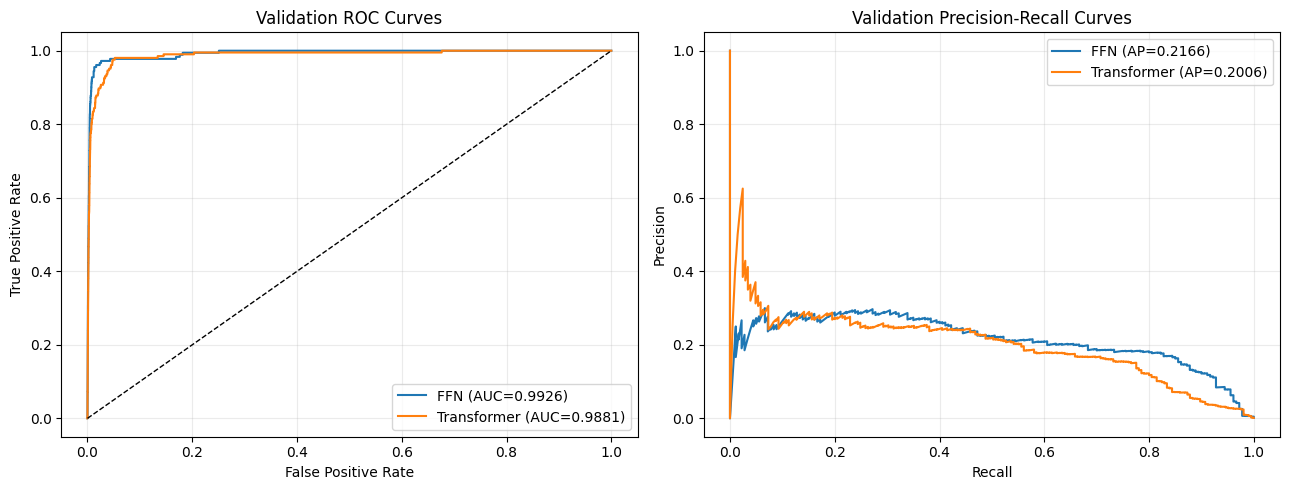

,roc_auc,average_precision
model,,
ffn,0.992627,0.216596
transformer,0.988061,0.200645


In [18]:
# Create ROC and PR curves for both models on their validation sets
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

# Reuse the same device used during training
device = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# Feed-forward model validation
# -----------------------------
val_X = X[cut_split["val_idx"]]
val_y = y[cut_split["val_idx"]].astype(np.float32).reshape(-1)

cut_model.eval()
with torch.no_grad():
    val_logits_ffn = cut_model(torch.from_numpy(val_X).float().to(device)).cpu().numpy().reshape(-1)
    val_probs_ffn = 1.0 / (1.0 + np.exp(-val_logits_ffn))

# ---------------------------------
# Transformer model validation setup
# ---------------------------------
val_seq_records = [sequence_records[i] for i in cut_transformer_split["val_idx"]]

val_seq_probs_list = []
val_seq_y_list = []

cut_transformer_model.eval()
with torch.no_grad():
    for i in range(0, len(val_seq_records), 4):
        batch_records = val_seq_records[i:i + 4]
        batch_X = [r["X"] for r in batch_records]
        batch_y = [r["y"] for r in batch_records]

        batch_lengths = [x.shape[0] for x in batch_X]
        max_len = max(batch_lengths)
        d_emb = batch_X[0].shape[1]

        x_pad = np.zeros((len(batch_X), max_len, d_emb), dtype=np.float32)
        y_pad = np.zeros((len(batch_X), max_len), dtype=np.float32)
        attn_mask = np.zeros((len(batch_X), max_len), dtype=np.float32)

        for j, (xj, yj) in enumerate(zip(batch_X, batch_y)):
            n = xj.shape[0]
            x_pad[j, :n, :] = xj
            y_pad[j, :n] = yj
            attn_mask[j, :n] = 1.0

        xb_tensor = torch.from_numpy(x_pad).float().to(device)
        attn_tensor = torch.from_numpy(attn_mask).float().to(device)

        logits_batch = cut_transformer_model(xb_tensor, attn_tensor).cpu().numpy()
        probs_batch = 1.0 / (1.0 + np.exp(-logits_batch))

        # Keep only real (unpadded) residues for metrics
        valid = attn_mask == 1.0
        val_seq_probs_list.append(probs_batch[valid])
        val_seq_y_list.append(y_pad[valid])

val_probs_tr = np.concatenate(val_seq_probs_list, axis=0).astype(np.float32)
val_y_tr = np.concatenate(val_seq_y_list, axis=0).astype(np.float32)

# ----------------
# Build all curves
# ----------------
results = {}

# FFN metrics
if np.unique(val_y).size >= 2:
    fpr_ffn, tpr_ffn, _ = roc_curve(val_y, val_probs_ffn)
    precision_ffn, recall_ffn, _ = precision_recall_curve(val_y, val_probs_ffn)
    roc_auc_ffn = auc(fpr_ffn, tpr_ffn)
    ap_ffn = average_precision_score(val_y, val_probs_ffn)
    results["ffn"] = {
        "fpr": fpr_ffn,
        "tpr": tpr_ffn,
        "precision": precision_ffn,
        "recall": recall_ffn,
        "roc_auc": roc_auc_ffn,
        "ap": ap_ffn,
    }
else:
    print("FFN validation labels contain a single class; ROC/PR cannot be computed.")

# Transformer metrics
if np.unique(val_y_tr).size >= 2:
    fpr_tr, tpr_tr, _ = roc_curve(val_y_tr, val_probs_tr)
    precision_tr, recall_tr, _ = precision_recall_curve(val_y_tr, val_probs_tr)
    roc_auc_tr = auc(fpr_tr, tpr_tr)
    ap_tr = average_precision_score(val_y_tr, val_probs_tr)
    results["transformer"] = {
        "fpr": fpr_tr,
        "tpr": tpr_tr,
        "precision": precision_tr,
        "recall": recall_tr,
        "roc_auc": roc_auc_tr,
        "ap": ap_tr,
    }
else:
    print("Transformer validation labels contain a single class; ROC/PR cannot be computed.")

# --------
# Plotting
# --------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
ax = axes[0]
if "ffn" in results:
    ax.plot(results["ffn"]["fpr"], results["ffn"]["tpr"], label=f"FFN (AUC={results['ffn']['roc_auc']:.4f})")
if "transformer" in results:
    ax.plot(results["transformer"]["fpr"], results["transformer"]["tpr"], label=f"Transformer (AUC={results['transformer']['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Validation ROC Curves")
ax.grid(alpha=0.25)
ax.legend()

# PR
ax = axes[1]
if "ffn" in results:
    ax.plot(results["ffn"]["recall"], results["ffn"]["precision"], label=f"FFN (AP={results['ffn']['ap']:.4f})")
if "transformer" in results:
    ax.plot(results["transformer"]["recall"], results["transformer"]["precision"], label=f"Transformer (AP={results['transformer']['ap']:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Validation Precision-Recall Curves")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

# Quick metric summary
metric_rows = []
if "ffn" in results:
    metric_rows.append({"model": "ffn", "roc_auc": results["ffn"]["roc_auc"], "average_precision": results["ffn"]["ap"]})
if "transformer" in results:
    metric_rows.append({"model": "transformer", "roc_auc": results["transformer"]["roc_auc"], "average_precision": results["transformer"]["ap"]})

pd.DataFrame(metric_rows).set_index("model") if metric_rows else None

pretty good. how does it do on a held out viral clade with limited learning data.

Available viral groups: ['Hepacivirus-CHH', 'Orthoflavivirus-CHH', 'Pegivirus-CHH', 'Pestivirus-CHH']

Holdout group: Orthoflavivirus-CHH
Train sequences: 70 | Test sequences: 161
Dropout -> FFN hidden: 0.45, FFN input: 0.1, Transformer hidden: 0.35, Transformer input: 0.08
Weight decay -> FFN: 0.0003, Transformer: 0.0003
OSCAR -> FFN(l1=1e-06, pair=2e-07), Transformer(l1=1e-06, pair=2e-07)
FFN train tokens: 226647 | positives: 319
FFN test tokens: 548672 | positives: 621


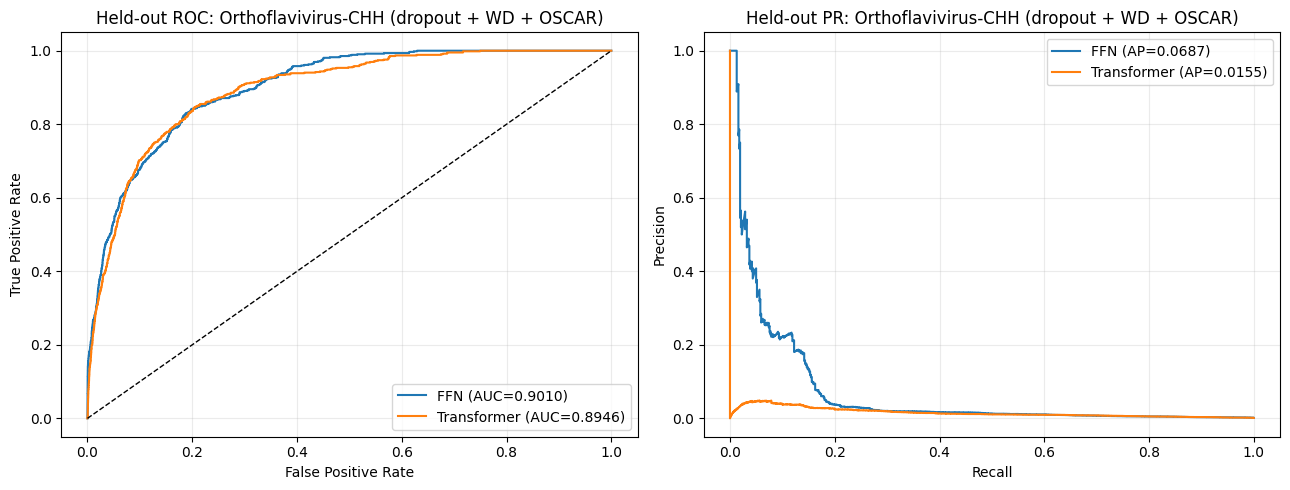

,heldout_group,roc_auc,average_precision,dropout,input_dropout,weight_decay,oscar_l1,oscar_pair
model,,,,,,,,
ffn,Orthoflavivirus-CHH,0.900950,0.068716,0.45,0.10,0.0003,0.000001,2.000000e-07
transformer,Orthoflavivirus-CHH,0.894615,0.015485,0.35,0.08,0.0003,0.000001,2.000000e-07


In [21]:
# Leave-one-viral-group-out validation
# Train on all groups except one held-out group, then evaluate on held-out group.
# This version adds stronger regularization: dropout + explicit weight decay + OSCAR penalty.

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score


def extract_group_name(source_file):
    p = Path(str(source_file))
    # Expected structure: .../Amarillovirales/<GroupName>/file
    # Use parent folder as group label.
    return p.parent.name


def build_group_sequence_records(embedding_df_local):
    """Build per-sequence records with group labels and binary cut masks."""
    rows = []
    df_local = embedding_df_local.reset_index().rename(columns={"index": "identifier"})

    for _, row in df_local.iterrows():
        emb = row.get("embedding_matrix", None)
        if emb is None:
            continue

        emb = np.asarray(emb, dtype=np.float32)
        if emb.ndim != 2 or emb.shape[0] == 0:
            continue

        n_aa = emb.shape[0]

        if "cut_site_mask" in row and row["cut_site_mask"] is not None:
            y = np.asarray(row["cut_site_mask"], dtype=np.float32).reshape(-1)
            if len(y) != n_aa:
                y = y[:n_aa] if len(y) > n_aa else np.pad(y, (0, n_aa - len(y)))
        elif "cut_site_positions" in row and row["cut_site_positions"] is not None:
            y = to_binary_mask(n_aa=n_aa, cut_positions=row["cut_site_positions"], one_based=True)
        else:
            continue

        group = extract_group_name(row["source_file"])
        rows.append(
            {
                "identifier": str(row["identifier"]),
                "group": group,
                "X": emb,
                "y": y.astype(np.float32),
            }
        )

    return rows


def oscar_penalty(weights, lambda_l1=0.0, lambda_pair=0.0):
    """
    OSCAR penalty for coefficient shrinkage + clustering:
      lambda_l1 * sum_i |w_i| + lambda_pair * sum_{i<j} max(|w_i|, |w_j|)

    Uses a sorted-vector identity for O(n log n) pairwise term:
      sum_{i<j} max(a_i, a_j) where a sorted descending = sum_k (n-k-1) * a_k
    """
    if lambda_l1 <= 0.0 and lambda_pair <= 0.0:
        return weights.new_tensor(0.0)

    w = weights.reshape(-1)
    a = torch.abs(w)

    penalty = weights.new_tensor(0.0)
    if lambda_l1 > 0.0:
        penalty = penalty + lambda_l1 * a.sum()

    if lambda_pair > 0.0 and a.numel() > 1:
        a_sorted, _ = torch.sort(a, descending=True)
        n = a_sorted.numel()
        coeff = torch.arange(n - 1, -1, -1, device=a_sorted.device, dtype=a_sorted.dtype)
        pair_term = (a_sorted * coeff).sum()
        penalty = penalty + lambda_pair * pair_term

    return penalty


def train_ffn_on_arrays(
    X_train,
    y_train,
    lr=1e-3,
    batch_size=2048,
    epochs=8,
    dropout=0.45,
    input_dropout=0.10,
    d_hidden=256,
    weight_decay=3e-4,
    oscar_lambda_l1=0.0,
    oscar_lambda_pair=0.0,
):
    device_local = "cuda" if torch.cuda.is_available() else "cpu"
    model = SmallCutSiteFFN(d_in=X_train.shape[1], d_hidden=d_hidden, dropout=dropout).to(device_local)

    ds = PositionDataset(X_train, y_train)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    n_pos = float(y_train.sum())
    n_neg = float(len(y_train) - n_pos)
    pos_weight = torch.tensor([max(1.0, n_neg / max(1.0, n_pos))], dtype=torch.float32, device=device_local)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device_local)
            yb = yb.to(device_local)
            if input_dropout > 0:
                xb = F.dropout(xb, p=input_dropout, training=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)

            # Apply OSCAR to the final linear layer to promote sparsity + grouped coefficients.
            if oscar_lambda_l1 > 0.0 or oscar_lambda_pair > 0.0:
                w_out = model.net[-1].weight
                loss = loss + oscar_penalty(w_out, lambda_l1=oscar_lambda_l1, lambda_pair=oscar_lambda_pair)

            loss.backward()
            optimizer.step()

    return model, device_local


def eval_ffn_arrays(model, X_eval, y_eval, device_local):
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(X_eval).float().to(device_local)).cpu().numpy().reshape(-1)
    probs = 1.0 / (1.0 + np.exp(-logits))
    y_eval = y_eval.astype(np.float32).reshape(-1)
    return probs, y_eval


def train_transformer_on_records(
    train_records,
    lr=1e-3,
    batch_size=4,
    epochs=8,
    d_model=256,
    nhead=8,
    num_layers=2,
    dropout=0.35,
    input_dropout=0.08,
    weight_decay=3e-4,
    oscar_lambda_l1=0.0,
    oscar_lambda_pair=0.0,
):
    device_local = "cuda" if torch.cuda.is_available() else "cpu"
    d_in = train_records[0]["X"].shape[1]

    model = SmallCutSiteTransformer(
        d_in=d_in,
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device_local)

    ds = SequencePositionDataset(train_records)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, collate_fn=collate_sequence_batch)

    y_train_all = np.concatenate([r["y"] for r in train_records])
    n_pos = float(y_train_all.sum())
    n_neg = float(len(y_train_all) - n_pos)
    pos_weight = torch.tensor([max(1.0, n_neg / max(1.0, n_pos))], dtype=torch.float32, device=device_local)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    for _ in range(epochs):
        model.train()
        for _, xb, yb, mb in loader:
            xb = xb.to(device_local)
            yb = yb.to(device_local)
            mb = mb.to(device_local)

            if input_dropout > 0:
                xb = F.dropout(xb, p=input_dropout, training=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb, mb)
            loss = masked_bce_with_logits(logits, yb, mb, pos_weight=pos_weight)

            # Apply OSCAR to the transformer output layer weights.
            if oscar_lambda_l1 > 0.0 or oscar_lambda_pair > 0.0:
                w_out = model.head[-1].weight
                loss = loss + oscar_penalty(w_out, lambda_l1=oscar_lambda_l1, lambda_pair=oscar_lambda_pair)

            loss.backward()
            optimizer.step()

    return model, device_local


def eval_transformer_records(model, eval_records, device_local, batch_size=4):
    model.eval()
    probs_all = []
    y_all = []

    with torch.no_grad():
        for i in range(0, len(eval_records), batch_size):
            batch = eval_records[i:i + batch_size]
            batch_X = [r["X"] for r in batch]
            batch_y = [r["y"] for r in batch]

            lengths = [x.shape[0] for x in batch_X]
            max_len = max(lengths)
            d_emb = batch_X[0].shape[1]

            x_pad = np.zeros((len(batch), max_len, d_emb), dtype=np.float32)
            y_pad = np.zeros((len(batch), max_len), dtype=np.float32)
            attn_mask = np.zeros((len(batch), max_len), dtype=np.float32)

            for j, (xj, yj) in enumerate(zip(batch_X, batch_y)):
                n = xj.shape[0]
                x_pad[j, :n, :] = xj
                y_pad[j, :n] = yj
                attn_mask[j, :n] = 1.0

            xb = torch.from_numpy(x_pad).float().to(device_local)
            mb = torch.from_numpy(attn_mask).float().to(device_local)
            logits = model(xb, mb).cpu().numpy()
            probs = 1.0 / (1.0 + np.exp(-logits))

            valid = attn_mask == 1.0
            probs_all.append(probs[valid])
            y_all.append(y_pad[valid])

    return np.concatenate(probs_all).astype(np.float32), np.concatenate(y_all).astype(np.float32)


def compute_curve_metrics(y_true, probs):
    if np.unique(y_true).size < 2:
        return None
    fpr, tpr, _ = roc_curve(y_true, probs)
    precision, recall, _ = precision_recall_curve(y_true, probs)
    return {
        "fpr": fpr,
        "tpr": tpr,
        "precision": precision,
        "recall": recall,
        "roc_auc": auc(fpr, tpr),
        "ap": average_precision_score(y_true, probs),
    }


# -------- CONFIG --------
# Change this to any group shown in the printout below.
holdout_group = "Orthoflavivirus-CHH"
ffn_epochs = 8
transformer_epochs = 8

# Dropout-focused robustness settings
ffn_dropout = 0.45
ffn_input_dropout = 0.10
transformer_dropout = 0.35
transformer_input_dropout = 0.08

# Additional regularization settings
ffn_weight_decay = 3e-4
transformer_weight_decay = 3e-4

# OSCAR strengths (keep small; pair term can be large)
ffn_oscar_lambda_l1 = 1e-6
ffn_oscar_lambda_pair = 2e-7
transformer_oscar_lambda_l1 = 1e-6
transformer_oscar_lambda_pair = 2e-7
# ------------------------

all_seq_records = build_group_sequence_records(embedding_df)
if not all_seq_records:
    raise ValueError("No sequence records with embeddings + cut-site labels were found.")

groups = sorted({r["group"] for r in all_seq_records})
print("Available viral groups:", groups)
if holdout_group not in groups:
    raise ValueError(f"holdout_group='{holdout_group}' not found. Choose from: {groups}")

train_records = [r for r in all_seq_records if r["group"] != holdout_group]
test_records = [r for r in all_seq_records if r["group"] == holdout_group]

print(f"\nHoldout group: {holdout_group}")
print(f"Train sequences: {len(train_records)} | Test sequences: {len(test_records)}")
print(
    f"Dropout -> FFN hidden: {ffn_dropout}, FFN input: {ffn_input_dropout}, "
    f"Transformer hidden: {transformer_dropout}, Transformer input: {transformer_input_dropout}"
)
print(
    f"Weight decay -> FFN: {ffn_weight_decay}, Transformer: {transformer_weight_decay}"
)
print(
    f"OSCAR -> FFN(l1={ffn_oscar_lambda_l1}, pair={ffn_oscar_lambda_pair}), "
    f"Transformer(l1={transformer_oscar_lambda_l1}, pair={transformer_oscar_lambda_pair})"
)

# Flatten for FFN training/eval
X_train_ffn = np.vstack([r["X"] for r in train_records]).astype(np.float32)
y_train_ffn = np.concatenate([r["y"] for r in train_records]).astype(np.float32)
X_test_ffn = np.vstack([r["X"] for r in test_records]).astype(np.float32)
y_test_ffn = np.concatenate([r["y"] for r in test_records]).astype(np.float32)

print(f"FFN train tokens: {len(y_train_ffn)} | positives: {int(y_train_ffn.sum())}")
print(f"FFN test tokens: {len(y_test_ffn)} | positives: {int(y_test_ffn.sum())}")

# Train + evaluate FFN
holdout_ffn_model, holdout_ffn_device = train_ffn_on_arrays(
    X_train_ffn,
    y_train_ffn,
    lr=1e-3,
    batch_size=2048,
    epochs=ffn_epochs,
    dropout=ffn_dropout,
    input_dropout=ffn_input_dropout,
    weight_decay=ffn_weight_decay,
    oscar_lambda_l1=ffn_oscar_lambda_l1,
    oscar_lambda_pair=ffn_oscar_lambda_pair,
)
ffn_probs, ffn_y = eval_ffn_arrays(holdout_ffn_model, X_test_ffn, y_test_ffn, holdout_ffn_device)
ffn_metrics = compute_curve_metrics(ffn_y, ffn_probs)

# Train + evaluate transformer
holdout_tr_model, holdout_tr_device = train_transformer_on_records(
    train_records,
    lr=1e-3,
    batch_size=4,
    epochs=transformer_epochs,
    d_model=256,
    nhead=8,
    num_layers=2,
    dropout=transformer_dropout,
    input_dropout=transformer_input_dropout,
    weight_decay=transformer_weight_decay,
    oscar_lambda_l1=transformer_oscar_lambda_l1,
    oscar_lambda_pair=transformer_oscar_lambda_pair,
)
tr_probs, tr_y = eval_transformer_records(holdout_tr_model, test_records, holdout_tr_device, batch_size=4)
tr_metrics = compute_curve_metrics(tr_y, tr_probs)

# Plot ROC and PR for held-out group
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
if ffn_metrics is not None:
    ax.plot(ffn_metrics["fpr"], ffn_metrics["tpr"], label=f"FFN (AUC={ffn_metrics['roc_auc']:.4f})")
if tr_metrics is not None:
    ax.plot(tr_metrics["fpr"], tr_metrics["tpr"], label=f"Transformer (AUC={tr_metrics['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"Held-out ROC: {holdout_group} (dropout + WD + OSCAR)")
ax.grid(alpha=0.25)
ax.legend()

ax = axes[1]
if ffn_metrics is not None:
    ax.plot(ffn_metrics["recall"], ffn_metrics["precision"], label=f"FFN (AP={ffn_metrics['ap']:.4f})")
if tr_metrics is not None:
    ax.plot(tr_metrics["recall"], tr_metrics["precision"], label=f"Transformer (AP={tr_metrics['ap']:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Held-out PR: {holdout_group} (dropout + WD + OSCAR)")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

# Summary table
summary_rows = []
if ffn_metrics is not None:
    summary_rows.append(
        {
            "model": "ffn",
            "heldout_group": holdout_group,
            "roc_auc": ffn_metrics["roc_auc"],
            "average_precision": ffn_metrics["ap"],
            "dropout": ffn_dropout,
            "input_dropout": ffn_input_dropout,
            "weight_decay": ffn_weight_decay,
            "oscar_l1": ffn_oscar_lambda_l1,
            "oscar_pair": ffn_oscar_lambda_pair,
        }
    )
if tr_metrics is not None:
    summary_rows.append(
        {
            "model": "transformer",
            "heldout_group": holdout_group,
            "roc_auc": tr_metrics["roc_auc"],
            "average_precision": tr_metrics["ap"],
            "dropout": transformer_dropout,
            "input_dropout": transformer_input_dropout,
            "weight_decay": transformer_weight_decay,
            "oscar_l1": transformer_oscar_lambda_l1,
            "oscar_pair": transformer_oscar_lambda_pair,
        }
    )

pd.DataFrame(summary_rows).set_index("model") if summary_rows else None

## Held-Out Clade Generalization and Regularization Tuning

To evaluate whether the model generalizes beyond its training distribution, we test on a **held-out viral clade** and focus on reducing overfitting through regularization.

### Why regularization?
With limited labeled data in the held-out setting, models can overfit training-specific patterns.  
Regularization improves robustness by encouraging smoother, more transferable decision boundaries.

### Hyperparameter search strategy
We run a **grid search** over key regularization settings and evaluate each configuration on the held-out validation split:

- **Weight decay**
- **Dropout**
- **Input dropout**
- **OSCAR penalties** (`oscar_l1`, `oscar_pair`)

### Model selection criterion
For each model family (FFN and Transformer), we rank configurations by held-out performance, primarily using:

- **Average Precision (PR-AUC)** for imbalanced cut-site labels
- **ROC-AUC** as a complementary ranking signal

The best-performing regularization setup is then retrained for a longer schedule and used for final held-out evaluation.


=== Running wd1e-4_no_oscar ===

=== Running wd3e-4_oscar_light ===

=== Running wd1e-3_oscar_light ===

=== Running wd3e-4_oscar_med ===

Sweep finished in 91.8 seconds

Top configs by AP (FFN):


,config,model,heldout_group,weight_decay,oscar_l1,oscar_pair,dropout,input_dropout,epochs,roc_auc,average_precision
0,wd1e-4_no_oscar,ffn,Orthoflavivirus-CHH,0.0001,0.000000,0.000000e+00,0.45,0.1,5,0.916543,0.071953
1,wd1e-3_oscar_light,ffn,Orthoflavivirus-CHH,0.0010,0.000001,2.000000e-07,0.45,0.1,5,0.911626,0.067489
2,wd3e-4_oscar_med,ffn,Orthoflavivirus-CHH,0.0003,0.000003,6.000000e-07,0.45,0.1,5,0.921821,0.064460
3,wd3e-4_oscar_light,ffn,Orthoflavivirus-CHH,0.0003,0.000001,2.000000e-07,0.45,0.1,5,0.904044,0.058684



Top configs by AP (Transformer):


,config,model,heldout_group,weight_decay,oscar_l1,oscar_pair,dropout,input_dropout,epochs,roc_auc,average_precision
0,wd3e-4_oscar_med,transformer,Orthoflavivirus-CHH,0.0003,0.000003,6.000000e-07,0.35,0.08,5,0.912698,0.040611
1,wd1e-4_no_oscar,transformer,Orthoflavivirus-CHH,0.0001,0.000000,0.000000e+00,0.35,0.08,5,0.913495,0.036786
2,wd3e-4_oscar_light,transformer,Orthoflavivirus-CHH,0.0003,0.000001,2.000000e-07,0.35,0.08,5,0.901911,0.030923
3,wd1e-3_oscar_light,transformer,Orthoflavivirus-CHH,0.0010,0.000001,2.000000e-07,0.35,0.08,5,0.932546,0.027902


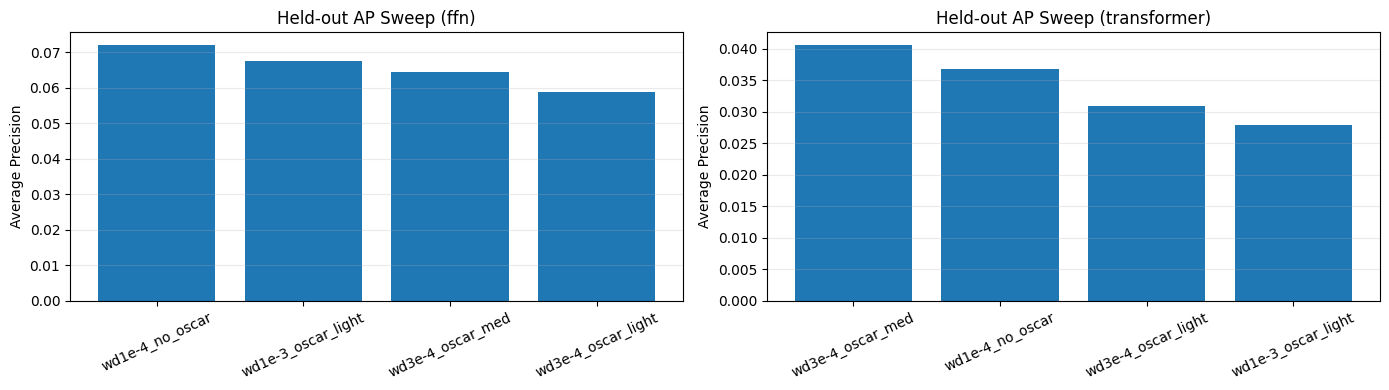

,config,model,heldout_group,weight_decay,oscar_l1,oscar_pair,dropout,input_dropout,epochs,roc_auc,average_precision
0,wd1e-4_no_oscar,ffn,Orthoflavivirus-CHH,0.0001,0.000000,0.000000e+00,0.45,0.10,5,0.916543,0.071953
1,wd1e-4_no_oscar,transformer,Orthoflavivirus-CHH,0.0001,0.000000,0.000000e+00,0.35,0.08,5,0.913495,0.036786
2,wd3e-4_oscar_light,ffn,Orthoflavivirus-CHH,0.0003,0.000001,2.000000e-07,0.45,0.10,5,0.904044,0.058684
3,wd3e-4_oscar_light,transformer,Orthoflavivirus-CHH,0.0003,0.000001,2.000000e-07,0.35,0.08,5,0.901911,0.030923
4,wd1e-3_oscar_light,ffn,Orthoflavivirus-CHH,0.0010,0.000001,2.000000e-07,0.45,0.10,5,0.911626,0.067489
5,wd1e-3_oscar_light,transformer,Orthoflavivirus-CHH,0.0010,0.000001,2.000000e-07,0.35,0.08,5,0.932546,0.027902
6,wd3e-4_oscar_med,ffn,Orthoflavivirus-CHH,0.0003,0.000003,6.000000e-07,0.45,0.10,5,0.921821,0.064460
7,wd3e-4_oscar_med,transformer,Orthoflavivirus-CHH,0.0003,0.000003,6.000000e-07,0.35,0.08,5,0.912698,0.040611


In [22]:
# Small regularization sweep on held-out group
# Sweeps weight decay + OSCAR strengths (dropout held fixed from Cell 11).

import time
import pandas as pd
import matplotlib.pyplot as plt

# Rebuild split in case Cell 11 was not just run
all_seq_records = build_group_sequence_records(embedding_df)
if not all_seq_records:
    raise ValueError("No sequence records with embeddings + cut-site labels were found.")

groups = sorted({r["group"] for r in all_seq_records})
holdout_group = holdout_group if "holdout_group" in globals() else "Orthoflavivirus-CHH"
if holdout_group not in groups:
    raise ValueError(f"holdout_group='{holdout_group}' not found. Choose from: {groups}")

train_records = [r for r in all_seq_records if r["group"] != holdout_group]
test_records = [r for r in all_seq_records if r["group"] == holdout_group]

X_train_ffn = np.vstack([r["X"] for r in train_records]).astype(np.float32)
y_train_ffn = np.concatenate([r["y"] for r in train_records]).astype(np.float32)
X_test_ffn = np.vstack([r["X"] for r in test_records]).astype(np.float32)
y_test_ffn = np.concatenate([r["y"] for r in test_records]).astype(np.float32)

# Keep this intentionally small for quick iteration
sweep_configs = [
    {"name": "wd1e-4_no_oscar", "wd": 1e-4, "os_l1": 0.0,   "os_pair": 0.0},
    {"name": "wd3e-4_oscar_light", "wd": 3e-4, "os_l1": 1e-6, "os_pair": 2e-7},
    {"name": "wd1e-3_oscar_light", "wd": 1e-3, "os_l1": 1e-6, "os_pair": 2e-7},
    {"name": "wd3e-4_oscar_med", "wd": 3e-4, "os_l1": 3e-6, "os_pair": 6e-7},
]

# Use fewer epochs for sweep speed, then retrain best config longer if needed
sweep_ffn_epochs = 5
sweep_transformer_epochs = 5

rows = []
start = time.time()

for cfg in sweep_configs:
    print("\n=== Running", cfg["name"], "===")

    # FFN
    model_ffn, dev_ffn = train_ffn_on_arrays(
        X_train_ffn,
        y_train_ffn,
        lr=1e-3,
        batch_size=2048,
        epochs=sweep_ffn_epochs,
        dropout=ffn_dropout,
        input_dropout=ffn_input_dropout,
        weight_decay=cfg["wd"],
        oscar_lambda_l1=cfg["os_l1"],
        oscar_lambda_pair=cfg["os_pair"],
    )
    probs_ffn, y_ffn = eval_ffn_arrays(model_ffn, X_test_ffn, y_test_ffn, dev_ffn)
    m_ffn = compute_curve_metrics(y_ffn, probs_ffn)

    rows.append(
        {
            "config": cfg["name"],
            "model": "ffn",
            "heldout_group": holdout_group,
            "weight_decay": cfg["wd"],
            "oscar_l1": cfg["os_l1"],
            "oscar_pair": cfg["os_pair"],
            "dropout": ffn_dropout,
            "input_dropout": ffn_input_dropout,
            "epochs": sweep_ffn_epochs,
            "roc_auc": None if m_ffn is None else m_ffn["roc_auc"],
            "average_precision": None if m_ffn is None else m_ffn["ap"],
        }
    )

    # Transformer
    model_tr, dev_tr = train_transformer_on_records(
        train_records,
        lr=1e-3,
        batch_size=4,
        epochs=sweep_transformer_epochs,
        d_model=256,
        nhead=8,
        num_layers=2,
        dropout=transformer_dropout,
        input_dropout=transformer_input_dropout,
        weight_decay=cfg["wd"],
        oscar_lambda_l1=cfg["os_l1"],
        oscar_lambda_pair=cfg["os_pair"],
    )
    probs_tr, y_tr = eval_transformer_records(model_tr, test_records, dev_tr, batch_size=4)
    m_tr = compute_curve_metrics(y_tr, probs_tr)

    rows.append(
        {
            "config": cfg["name"],
            "model": "transformer",
            "heldout_group": holdout_group,
            "weight_decay": cfg["wd"],
            "oscar_l1": cfg["os_l1"],
            "oscar_pair": cfg["os_pair"],
            "dropout": transformer_dropout,
            "input_dropout": transformer_input_dropout,
            "epochs": sweep_transformer_epochs,
            "roc_auc": None if m_tr is None else m_tr["roc_auc"],
            "average_precision": None if m_tr is None else m_tr["ap"],
        }
    )

sweep_df = pd.DataFrame(rows)
print(f"\nSweep finished in {(time.time() - start):.1f} seconds")

# Ranked tables
print("\nTop configs by AP (FFN):")
display(sweep_df[sweep_df["model"] == "ffn"].sort_values("average_precision", ascending=False).reset_index(drop=True))

print("\nTop configs by AP (Transformer):")
display(sweep_df[sweep_df["model"] == "transformer"].sort_values("average_precision", ascending=False).reset_index(drop=True))

# Quick visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for model_name, ax in zip(["ffn", "transformer"], axes):
    sub = sweep_df[sweep_df["model"] == model_name].sort_values("average_precision", ascending=False)
    ax.bar(sub["config"], sub["average_precision"])
    ax.set_title(f"Held-out AP Sweep ({model_name})")
    ax.set_ylabel("Average Precision")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

sweep_df

Using best FFN config:


,config,model,heldout_group,weight_decay,oscar_l1,oscar_pair,dropout,input_dropout,epochs,roc_auc,average_precision
0,wd1e-4_no_oscar,ffn,Orthoflavivirus-CHH,0.0001,0.0,0.0,0.45,0.1,5,0.916543,0.071953


Using best Transformer config:


,config,model,heldout_group,weight_decay,oscar_l1,oscar_pair,dropout,input_dropout,epochs,roc_auc,average_precision
7,wd3e-4_oscar_med,transformer,Orthoflavivirus-CHH,0.0003,0.000003,0.000001,0.35,0.08,5,0.912698,0.040611


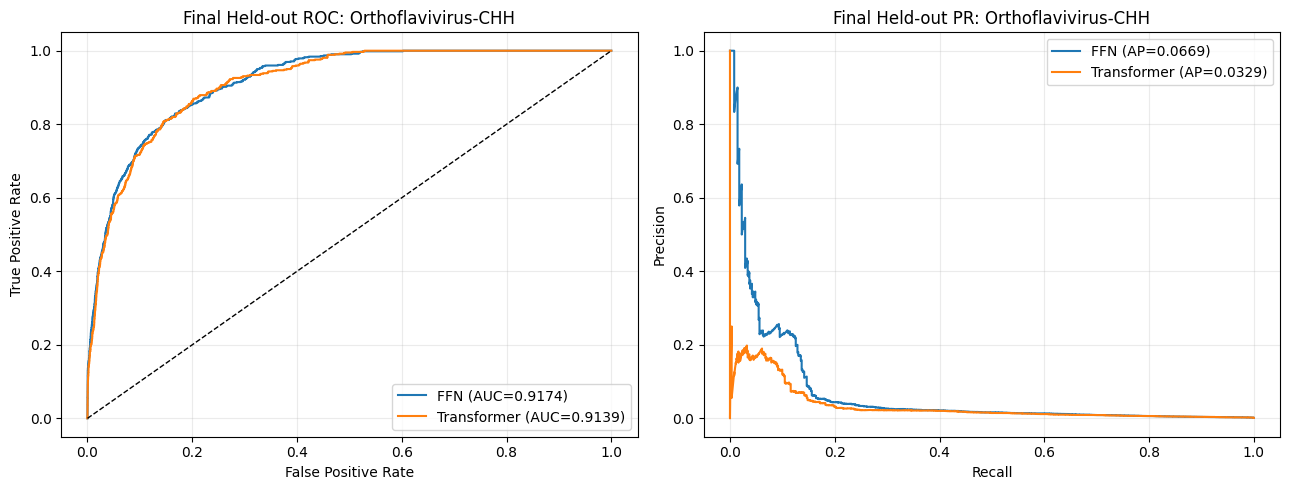

,heldout_group,epochs,roc_auc,average_precision,dropout,input_dropout,weight_decay,oscar_l1,oscar_pair,source_config
model,,,,,,,,,,
ffn,Orthoflavivirus-CHH,12,0.917361,0.066899,0.45,0.10,0.0001,0.000000,0.000000e+00,wd1e-4_no_oscar
transformer,Orthoflavivirus-CHH,12,0.913887,0.032863,0.35,0.08,0.0003,0.000003,6.000000e-07,wd3e-4_oscar_med


In [23]:
# Final held-out run for both nets using best sweep hyperparameters
# Picks best AP config per model from sweep_df, retrains longer, and reports final metrics.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "sweep_df" not in globals() or sweep_df is None or len(sweep_df) == 0:
    raise ValueError("sweep_df not found. Run Cell 12 (the sweep cell) first.")

# Resolve holdout split
all_seq_records = build_group_sequence_records(embedding_df)
groups = sorted({r["group"] for r in all_seq_records})
holdout_group_final = holdout_group if "holdout_group" in globals() else "Orthoflavivirus-CHH"
if holdout_group_final not in groups:
    raise ValueError(f"holdout_group='{holdout_group_final}' not found. Choose from: {groups}")

train_records = [r for r in all_seq_records if r["group"] != holdout_group_final]
test_records = [r for r in all_seq_records if r["group"] == holdout_group_final]

X_train_ffn = np.vstack([r["X"] for r in train_records]).astype(np.float32)
y_train_ffn = np.concatenate([r["y"] for r in train_records]).astype(np.float32)
X_test_ffn = np.vstack([r["X"] for r in test_records]).astype(np.float32)
y_test_ffn = np.concatenate([r["y"] for r in test_records]).astype(np.float32)

# Best AP config per model from sweep
best_ffn = sweep_df[sweep_df["model"] == "ffn"].sort_values("average_precision", ascending=False).iloc[0]
best_tr = sweep_df[sweep_df["model"] == "transformer"].sort_values("average_precision", ascending=False).iloc[0]

# Final training epochs (longer than sweep)
final_ffn_epochs = 12
final_transformer_epochs = 12

print("Using best FFN config:")
display(best_ffn.to_frame().T)
print("Using best Transformer config:")
display(best_tr.to_frame().T)

# Train/eval FFN final
final_ffn_model, final_ffn_device = train_ffn_on_arrays(
    X_train_ffn,
    y_train_ffn,
    lr=1e-3,
    batch_size=2048,
    epochs=final_ffn_epochs,
    dropout=float(best_ffn["dropout"]),
    input_dropout=float(best_ffn["input_dropout"]),
    weight_decay=float(best_ffn["weight_decay"]),
    oscar_lambda_l1=float(best_ffn["oscar_l1"]),
    oscar_lambda_pair=float(best_ffn["oscar_pair"]),
)
final_ffn_probs, final_ffn_y = eval_ffn_arrays(final_ffn_model, X_test_ffn, y_test_ffn, final_ffn_device)
final_ffn_metrics = compute_curve_metrics(final_ffn_y, final_ffn_probs)

# Train/eval Transformer final
final_tr_model, final_tr_device = train_transformer_on_records(
    train_records,
    lr=1e-3,
    batch_size=4,
    epochs=final_transformer_epochs,
    d_model=256,
    nhead=8,
    num_layers=2,
    dropout=float(best_tr["dropout"]),
    input_dropout=float(best_tr["input_dropout"]),
    weight_decay=float(best_tr["weight_decay"]),
    oscar_lambda_l1=float(best_tr["oscar_l1"]),
    oscar_lambda_pair=float(best_tr["oscar_pair"]),
)
final_tr_probs, final_tr_y = eval_transformer_records(final_tr_model, test_records, final_tr_device, batch_size=4)
final_tr_metrics = compute_curve_metrics(final_tr_y, final_tr_probs)

# Plot final ROC + PR
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
if final_ffn_metrics is not None:
    ax.plot(final_ffn_metrics["fpr"], final_ffn_metrics["tpr"], label=f"FFN (AUC={final_ffn_metrics['roc_auc']:.4f})")
if final_tr_metrics is not None:
    ax.plot(final_tr_metrics["fpr"], final_tr_metrics["tpr"], label=f"Transformer (AUC={final_tr_metrics['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"Final Held-out ROC: {holdout_group_final}")
ax.grid(alpha=0.25)
ax.legend()

ax = axes[1]
if final_ffn_metrics is not None:
    ax.plot(final_ffn_metrics["recall"], final_ffn_metrics["precision"], label=f"FFN (AP={final_ffn_metrics['ap']:.4f})")
if final_tr_metrics is not None:
    ax.plot(final_tr_metrics["recall"], final_tr_metrics["precision"], label=f"Transformer (AP={final_tr_metrics['ap']:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Final Held-out PR: {holdout_group_final}")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

# Final summary table
final_rows = []
if final_ffn_metrics is not None:
    final_rows.append(
        {
            "model": "ffn",
            "heldout_group": holdout_group_final,
            "epochs": final_ffn_epochs,
            "roc_auc": final_ffn_metrics["roc_auc"],
            "average_precision": final_ffn_metrics["ap"],
            "dropout": float(best_ffn["dropout"]),
            "input_dropout": float(best_ffn["input_dropout"]),
            "weight_decay": float(best_ffn["weight_decay"]),
            "oscar_l1": float(best_ffn["oscar_l1"]),
            "oscar_pair": float(best_ffn["oscar_pair"]),
            "source_config": best_ffn["config"],
        }
    )
if final_tr_metrics is not None:
    final_rows.append(
        {
            "model": "transformer",
            "heldout_group": holdout_group_final,
            "epochs": final_transformer_epochs,
            "roc_auc": final_tr_metrics["roc_auc"],
            "average_precision": final_tr_metrics["ap"],
            "dropout": float(best_tr["dropout"]),
            "input_dropout": float(best_tr["input_dropout"]),
            "weight_decay": float(best_tr["weight_decay"]),
            "oscar_l1": float(best_tr["oscar_l1"]),
            "oscar_pair": float(best_tr["oscar_pair"]),
            "source_config": best_tr["config"],
        }
    )

final_run_df = pd.DataFrame(final_rows).set_index("model")
final_run_df

## Final Model Training and Export

Using the best hyperparameter configuration, the final models are trained on all labeled data and saved for deployment and downstream analysis.

### Saved artifacts
- **PyTorch checkpoints** for both classifier heads (FFN and Transformer)
- **Model metadata bundle** with training settings and checkpoint paths

### Deployment readiness
These artifacts can be loaded directly for inference on new sequences, enabling reproducible prediction workflows outside the notebook.

## OSCAR on Input Embeddings

I ran a small experiment to test whether applying OSCAR regularization to the input embeddings improves generalization.

### Motivation
- The goal is to encourage smoother and more structured representations at the input layer.
- This may help the model transfer more effectively to a held-out viral clade with limited supervision.

### Experiment
- Apply OSCAR penalties to the input-weight matrix, in addition to the output layer.
- Sweep the OSCAR hyperparameters over a small grid.
- Evaluate each configuration on the held-out validation set using:
	- ROC-AUC
	- Average Precision (PR-AUC)

This setup allows us to assess whether input-level regularization helps robustness or simply reduces model capacity.

In [26]:
# Train on all labeled data with selected hyperparameters and save small classifier checkpoints for CLI use
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch

# Resolve all labeled sequence records
all_seq_records = build_group_sequence_records(embedding_df)
if not all_seq_records:
    raise ValueError("No sequence records with embeddings + cut-site labels were found.")

# Resolve best hyperparameters from final_run_df (preferred) or sweep_df (fallback)
if "final_run_df" in globals() and final_run_df is not None and len(final_run_df) > 0:
    ffn_row = final_run_df.loc["ffn"] if "ffn" in final_run_df.index else None
    tr_row = final_run_df.loc["transformer"] if "transformer" in final_run_df.index else None
elif "sweep_df" in globals() and sweep_df is not None and len(sweep_df) > 0:
    ffn_row = sweep_df[sweep_df["model"] == "ffn"].sort_values("average_precision", ascending=False).iloc[0]
    tr_row = sweep_df[sweep_df["model"] == "transformer"].sort_values("average_precision", ascending=False).iloc[0]
else:
    raise ValueError("No final_run_df or sweep_df found. Run the sweep/final-run cells first.")

if ffn_row is None or tr_row is None:
    raise ValueError("Could not resolve both FFN and transformer hyperparameters.")

# Training schedule for final all-data fit
all_train_ffn_epochs = 16
all_train_transformer_epochs = 16

# Flatten token-level arrays for FFN
X_all_ffn = np.vstack([r["X"] for r in all_seq_records]).astype(np.float32)
y_all_ffn = np.concatenate([r["y"] for r in all_seq_records]).astype(np.float32)

print(f"All-data sequences: {len(all_seq_records)}")
print(f"All-data token labels: {len(y_all_ffn)} | positives: {int(y_all_ffn.sum())}")

# Train FFN on all data
final_all_ffn_model, final_all_ffn_device = train_ffn_on_arrays(
    X_all_ffn,
    y_all_ffn,
    lr=1e-3,
    batch_size=2048,
    epochs=all_train_ffn_epochs,
    dropout=float(ffn_row["dropout"]),
    input_dropout=float(ffn_row["input_dropout"]),
    weight_decay=float(ffn_row["weight_decay"]),
    oscar_lambda_l1=float(ffn_row["oscar_l1"]),
    oscar_lambda_pair=float(ffn_row["oscar_pair"]),
)

# Train transformer on all data
final_all_tr_model, final_all_tr_device = train_transformer_on_records(
    all_seq_records,
    lr=1e-3,
    batch_size=4,
    epochs=all_train_transformer_epochs,
    d_model=256,
    nhead=8,
    num_layers=2,
    dropout=float(tr_row["dropout"]),
    input_dropout=float(tr_row["input_dropout"]),
    weight_decay=float(tr_row["weight_decay"]),
    oscar_lambda_l1=float(tr_row["oscar_l1"]),
    oscar_lambda_pair=float(tr_row["oscar_pair"]),
)

# Save compact classifier checkpoints for CLI
model_out_dir = Path("polyprotein_cut/models")
model_out_dir.mkdir(parents=True, exist_ok=True)

ffn_ckpt_path = model_out_dir / "cutsite_ffn_all_data.pt"
tr_ckpt_path = model_out_dir / "cutsite_transformer_all_data.pt"
meta_path = model_out_dir / "cutsite_model_bundle_metadata.json"

# Input embedding dimensionality
ffn_d_in = int(X_all_ffn.shape[1])
tr_d_in = int(all_seq_records[0]["X"].shape[1])

# Capture which ESM checkpoint was used upstream when available
esm_ckpt_used = checkpoint_path if "checkpoint_path" in globals() else None

ffn_payload = {
    "model_type": "ffn",
    "state_dict": final_all_ffn_model.state_dict(),
    "d_in": ffn_d_in,
    "d_hidden": int(final_all_ffn_model.net[0].out_features),
    "dropout": float(ffn_row["dropout"]),
    "input_dropout": float(ffn_row["input_dropout"]),
    "weight_decay": float(ffn_row["weight_decay"]),
    "oscar_l1": float(ffn_row["oscar_l1"]),
    "oscar_pair": float(ffn_row["oscar_pair"]),
    "train_epochs": int(all_train_ffn_epochs),
    "lr": 1e-3,
    "n_sequences": int(len(all_seq_records)),
    "n_tokens": int(len(y_all_ffn)),
    "n_positive_tokens": int(y_all_ffn.sum()),
    "esm3di_checkpoint": esm_ckpt_used,
}

total_tokens = int(sum(len(r["y"]) for r in all_seq_records))
total_positive = int(sum(float(np.asarray(r["y"]).sum()) for r in all_seq_records))

tr_payload = {
    "model_type": "transformer",
    "state_dict": final_all_tr_model.state_dict(),
    "d_in": tr_d_in,
    "d_model": int(final_all_tr_model.input_proj.out_features),
    "nhead": 8,
    "num_layers": 2,
    "dropout": float(tr_row["dropout"]),
    "input_dropout": float(tr_row["input_dropout"]),
    "weight_decay": float(tr_row["weight_decay"]),
    "oscar_l1": float(tr_row["oscar_l1"]),
    "oscar_pair": float(tr_row["oscar_pair"]),
    "train_epochs": int(all_train_transformer_epochs),
    "lr": 1e-3,
    "n_sequences": int(len(all_seq_records)),
    "n_tokens": total_tokens,
    "n_positive_tokens": total_positive,
    "esm3di_checkpoint": esm_ckpt_used,
}

torch.save(ffn_payload, ffn_ckpt_path)
torch.save(tr_payload, tr_ckpt_path)

bundle_meta = {
    "ffn_checkpoint": str(ffn_ckpt_path),
    "transformer_checkpoint": str(tr_ckpt_path),
    "esm3di_checkpoint": esm_ckpt_used,
    "cutoff_default": 0.5,
    "suggested_cli": {
        "module": "python -m esm3di.cutting_cli",
        "script": "esm3di-cut",
    },
}

with meta_path.open("w", encoding="utf-8") as f:
    json.dump(bundle_meta, f, indent=2)

saved_df = pd.DataFrame([
    {
        "model": "ffn",
        "checkpoint": str(ffn_ckpt_path),
        "device_trained": final_all_ffn_device,
        "dropout": float(ffn_row["dropout"]),
        "input_dropout": float(ffn_row["input_dropout"]),
        "weight_decay": float(ffn_row["weight_decay"]),
        "oscar_l1": float(ffn_row["oscar_l1"]),
        "oscar_pair": float(ffn_row["oscar_pair"]),
        "epochs": int(all_train_ffn_epochs),
    },
    {
        "model": "transformer",
        "checkpoint": str(tr_ckpt_path),
        "device_trained": final_all_tr_device,
        "dropout": float(tr_row["dropout"]),
        "input_dropout": float(tr_row["input_dropout"]),
        "weight_decay": float(tr_row["weight_decay"]),
        "oscar_l1": float(tr_row["oscar_l1"]),
        "oscar_pair": float(tr_row["oscar_pair"]),
        "epochs": int(all_train_transformer_epochs),
    },
]).set_index("model")

print("Saved model artifacts:")
print(f"- {ffn_ckpt_path}")
print(f"- {tr_ckpt_path}")
print(f"- {meta_path}")
saved_df

All-data sequences: 231
All-data token labels: 775319 | positives: 940
Saved model artifacts:
- polyprotein_cut/models/cutsite_ffn_all_data.pt
- polyprotein_cut/models/cutsite_transformer_all_data.pt
- polyprotein_cut/models/cutsite_model_bundle_metadata.json


,checkpoint,device_trained,dropout,input_dropout,weight_decay,oscar_l1,oscar_pair,epochs
model,,,,,,,,
ffn,polyprotein_cut/models/cutsite_ffn_all_data.pt,cuda,0.45,0.10,0.0001,0.000000,0.000000e+00,16
transformer,polyprotein_cut/models/cutsite_transformer_all...,cuda,0.35,0.08,0.0003,0.000003,6.000000e-07,16


Holdout group: Orthoflavivirus-CHH
Applying OSCAR to input and output weights:
FFN in/out OSCAR: l1=1e-06/1e-06, pair=2e-07/2e-07
TR  in/out OSCAR: l1=1e-06/1e-06, pair=2e-07/2e-07


,model,setting,roc_auc,average_precision
0,ffn,previous_final,0.917361,0.066899
1,transformer,previous_final,0.913887,0.032863
2,ffn,input+output_oscar,0.730082,0.002369
3,transformer,input+output_oscar,0.506302,0.001053


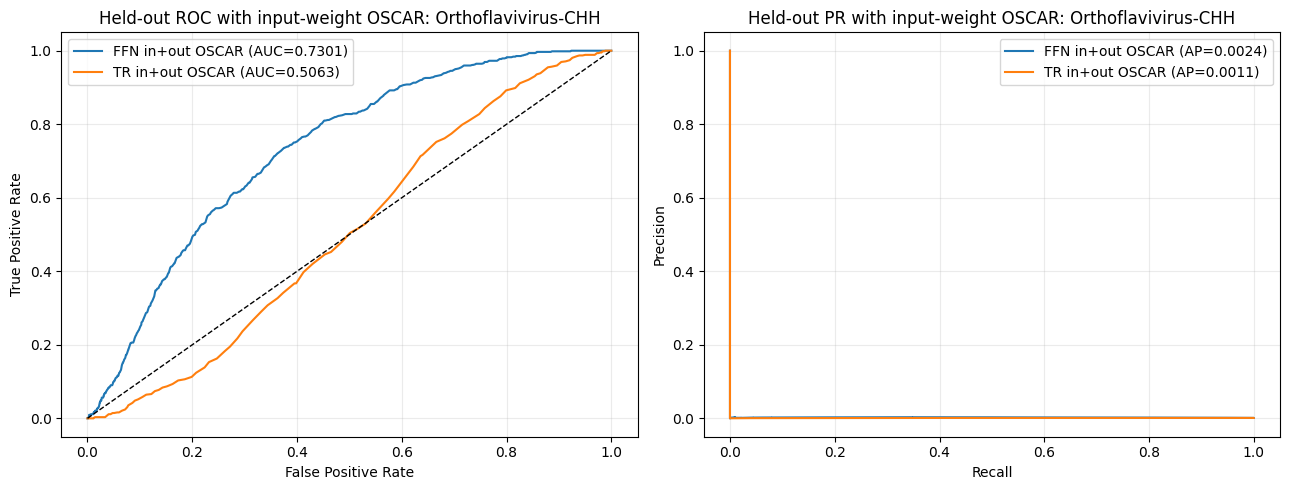

In [25]:
# Try applying OSCAR to input weights as well (FFN input layer + Transformer input projection)
# This cell defines input-weight OSCAR training variants and runs a held-out comparison.

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


def train_ffn_on_arrays_input_oscar(
    X_train,
    y_train,
    lr=1e-3,
    batch_size=2048,
    epochs=8,
    dropout=0.45,
    input_dropout=0.10,
    d_hidden=256,
    weight_decay=3e-4,
    oscar_out_lambda_l1=0.0,
    oscar_out_lambda_pair=0.0,
    oscar_in_lambda_l1=0.0,
    oscar_in_lambda_pair=0.0,
):
    device_local = "cuda" if torch.cuda.is_available() else "cpu"
    model = SmallCutSiteFFN(d_in=X_train.shape[1], d_hidden=d_hidden, dropout=dropout).to(device_local)

    ds = PositionDataset(X_train, y_train)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    n_pos = float(y_train.sum())
    n_neg = float(len(y_train) - n_pos)
    pos_weight = torch.tensor([max(1.0, n_neg / max(1.0, n_pos))], dtype=torch.float32, device=device_local)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device_local)
            yb = yb.to(device_local)
            if input_dropout > 0:
                xb = F.dropout(xb, p=input_dropout, training=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)

            # OSCAR on output layer
            if oscar_out_lambda_l1 > 0.0 or oscar_out_lambda_pair > 0.0:
                w_out = model.net[-1].weight
                loss = loss + oscar_penalty(w_out, lambda_l1=oscar_out_lambda_l1, lambda_pair=oscar_out_lambda_pair)

            # OSCAR on input layer
            if oscar_in_lambda_l1 > 0.0 or oscar_in_lambda_pair > 0.0:
                w_in = model.net[0].weight
                loss = loss + oscar_penalty(w_in, lambda_l1=oscar_in_lambda_l1, lambda_pair=oscar_in_lambda_pair)

            loss.backward()
            optimizer.step()

    return model, device_local


def train_transformer_on_records_input_oscar(
    train_records,
    lr=1e-3,
    batch_size=4,
    epochs=8,
    d_model=256,
    nhead=8,
    num_layers=2,
    dropout=0.35,
    input_dropout=0.08,
    weight_decay=3e-4,
    oscar_out_lambda_l1=0.0,
    oscar_out_lambda_pair=0.0,
    oscar_in_lambda_l1=0.0,
    oscar_in_lambda_pair=0.0,
):
    device_local = "cuda" if torch.cuda.is_available() else "cpu"
    d_in = train_records[0]["X"].shape[1]

    model = SmallCutSiteTransformer(
        d_in=d_in,
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device_local)

    ds = SequencePositionDataset(train_records)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, collate_fn=collate_sequence_batch)

    y_train_all = np.concatenate([r["y"] for r in train_records])
    n_pos = float(y_train_all.sum())
    n_neg = float(len(y_train_all) - n_pos)
    pos_weight = torch.tensor([max(1.0, n_neg / max(1.0, n_pos))], dtype=torch.float32, device=device_local)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    for _ in range(epochs):
        model.train()
        for _, xb, yb, mb in loader:
            xb = xb.to(device_local)
            yb = yb.to(device_local)
            mb = mb.to(device_local)

            if input_dropout > 0:
                xb = F.dropout(xb, p=input_dropout, training=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb, mb)
            loss = masked_bce_with_logits(logits, yb, mb, pos_weight=pos_weight)

            # OSCAR on output layer
            if oscar_out_lambda_l1 > 0.0 or oscar_out_lambda_pair > 0.0:
                w_out = model.head[-1].weight
                loss = loss + oscar_penalty(w_out, lambda_l1=oscar_out_lambda_l1, lambda_pair=oscar_out_lambda_pair)

            # OSCAR on input projection layer
            if oscar_in_lambda_l1 > 0.0 or oscar_in_lambda_pair > 0.0:
                w_in = model.input_proj.weight
                loss = loss + oscar_penalty(w_in, lambda_l1=oscar_in_lambda_l1, lambda_pair=oscar_in_lambda_pair)

            loss.backward()
            optimizer.step()

    return model, device_local


# Build hold-out split (reuse current setting if present)
all_seq_records = build_group_sequence_records(embedding_df)
if not all_seq_records:
    raise ValueError("No sequence records with embeddings + cut-site labels were found.")

groups = sorted({r["group"] for r in all_seq_records})
holdout_group_input_oscar = holdout_group if "holdout_group" in globals() else "Orthoflavivirus-CHH"
if holdout_group_input_oscar not in groups:
    raise ValueError(f"holdout_group='{holdout_group_input_oscar}' not found. Choose from: {groups}")

train_records = [r for r in all_seq_records if r["group"] != holdout_group_input_oscar]
test_records = [r for r in all_seq_records if r["group"] == holdout_group_input_oscar]

X_train_ffn = np.vstack([r["X"] for r in train_records]).astype(np.float32)
y_train_ffn = np.concatenate([r["y"] for r in train_records]).astype(np.float32)
X_test_ffn = np.vstack([r["X"] for r in test_records]).astype(np.float32)
y_test_ffn = np.concatenate([r["y"] for r in test_records]).astype(np.float32)

# Use existing hyperparams if present; otherwise fallback to defaults from earlier cells
ffn_dropout_use = float(ffn_dropout) if "ffn_dropout" in globals() else 0.45
ffn_input_dropout_use = float(ffn_input_dropout) if "ffn_input_dropout" in globals() else 0.10
ffn_weight_decay_use = float(ffn_weight_decay) if "ffn_weight_decay" in globals() else 3e-4
ffn_out_l1_use = float(ffn_oscar_lambda_l1) if "ffn_oscar_lambda_l1" in globals() else 1e-6
ffn_out_pair_use = float(ffn_oscar_lambda_pair) if "ffn_oscar_lambda_pair" in globals() else 2e-7

tr_dropout_use = float(transformer_dropout) if "transformer_dropout" in globals() else 0.35
tr_input_dropout_use = float(transformer_input_dropout) if "transformer_input_dropout" in globals() else 0.08
tr_weight_decay_use = float(transformer_weight_decay) if "transformer_weight_decay" in globals() else 3e-4
tr_out_l1_use = float(transformer_oscar_lambda_l1) if "transformer_oscar_lambda_l1" in globals() else 1e-6
tr_out_pair_use = float(transformer_oscar_lambda_pair) if "transformer_oscar_lambda_pair" in globals() else 2e-7

# New: apply same OSCAR strength to input weights
ffn_in_l1_use = ffn_out_l1_use
ffn_in_pair_use = ffn_out_pair_use
tr_in_l1_use = tr_out_l1_use
tr_in_pair_use = tr_out_pair_use

epochs_use = 8
print(f"Holdout group: {holdout_group_input_oscar}")
print("Applying OSCAR to input and output weights:")
print(f"FFN in/out OSCAR: l1={ffn_in_l1_use}/{ffn_out_l1_use}, pair={ffn_in_pair_use}/{ffn_out_pair_use}")
print(f"TR  in/out OSCAR: l1={tr_in_l1_use}/{tr_out_l1_use}, pair={tr_in_pair_use}/{tr_out_pair_use}")

# Train and evaluate FFN
ffn_model_in_oscar, ffn_dev_in_oscar = train_ffn_on_arrays_input_oscar(
    X_train_ffn,
    y_train_ffn,
    lr=1e-3,
    batch_size=2048,
    epochs=epochs_use,
    dropout=ffn_dropout_use,
    input_dropout=ffn_input_dropout_use,
    weight_decay=ffn_weight_decay_use,
    oscar_out_lambda_l1=ffn_out_l1_use,
    oscar_out_lambda_pair=ffn_out_pair_use,
    oscar_in_lambda_l1=ffn_in_l1_use,
    oscar_in_lambda_pair=ffn_in_pair_use,
)

ffn_probs_in_oscar, ffn_y_in_oscar = eval_ffn_arrays(ffn_model_in_oscar, X_test_ffn, y_test_ffn, ffn_dev_in_oscar)
ffn_metrics_in_oscar = compute_curve_metrics(ffn_y_in_oscar, ffn_probs_in_oscar)

# Train and evaluate Transformer
tr_model_in_oscar, tr_dev_in_oscar = train_transformer_on_records_input_oscar(
    train_records,
    lr=1e-3,
    batch_size=4,
    epochs=epochs_use,
    d_model=256,
    nhead=8,
    num_layers=2,
    dropout=tr_dropout_use,
    input_dropout=tr_input_dropout_use,
    weight_decay=tr_weight_decay_use,
    oscar_out_lambda_l1=tr_out_l1_use,
    oscar_out_lambda_pair=tr_out_pair_use,
    oscar_in_lambda_l1=tr_in_l1_use,
    oscar_in_lambda_pair=tr_in_pair_use,
)

tr_probs_in_oscar, tr_y_in_oscar = eval_transformer_records(tr_model_in_oscar, test_records, tr_dev_in_oscar, batch_size=4)
tr_metrics_in_oscar = compute_curve_metrics(tr_y_in_oscar, tr_probs_in_oscar)

# Compare with the most recent held-out metrics if present
rows = []
if "final_ffn_metrics" in globals() and final_ffn_metrics is not None:
    rows.append({"model": "ffn", "setting": "previous_final", "roc_auc": final_ffn_metrics["roc_auc"], "average_precision": final_ffn_metrics["ap"]})
if "final_tr_metrics" in globals() and final_tr_metrics is not None:
    rows.append({"model": "transformer", "setting": "previous_final", "roc_auc": final_tr_metrics["roc_auc"], "average_precision": final_tr_metrics["ap"]})

if ffn_metrics_in_oscar is not None:
    rows.append({"model": "ffn", "setting": "input+output_oscar", "roc_auc": ffn_metrics_in_oscar["roc_auc"], "average_precision": ffn_metrics_in_oscar["ap"]})
if tr_metrics_in_oscar is not None:
    rows.append({"model": "transformer", "setting": "input+output_oscar", "roc_auc": tr_metrics_in_oscar["roc_auc"], "average_precision": tr_metrics_in_oscar["ap"]})

comparison_df_input_oscar = pd.DataFrame(rows)
display(comparison_df_input_oscar)

# Plot ROC/PR for the new run
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
if ffn_metrics_in_oscar is not None:
    ax.plot(ffn_metrics_in_oscar["fpr"], ffn_metrics_in_oscar["tpr"], label=f"FFN in+out OSCAR (AUC={ffn_metrics_in_oscar['roc_auc']:.4f})")
if tr_metrics_in_oscar is not None:
    ax.plot(tr_metrics_in_oscar["fpr"], tr_metrics_in_oscar["tpr"], label=f"TR in+out OSCAR (AUC={tr_metrics_in_oscar['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"Held-out ROC with input-weight OSCAR: {holdout_group_input_oscar}")
ax.grid(alpha=0.25)
ax.legend()

ax = axes[1]
if ffn_metrics_in_oscar is not None:
    ax.plot(ffn_metrics_in_oscar["recall"], ffn_metrics_in_oscar["precision"], label=f"FFN in+out OSCAR (AP={ffn_metrics_in_oscar['ap']:.4f})")
if tr_metrics_in_oscar is not None:
    ax.plot(tr_metrics_in_oscar["recall"], tr_metrics_in_oscar["precision"], label=f"TR in+out OSCAR (AP={tr_metrics_in_oscar['ap']:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Held-out PR with input-weight OSCAR: {holdout_group_input_oscar}")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()


in the end... not so great. let's just use the first one...
